# Customer Segmentation Analysis

This notebook demonstrates multiple customer segmentation methodologies:

**Unsupervised Methods:**
- K-Means Clustering
- Hierarchical Clustering
- DBSCAN
- Gaussian Mixture Models
- RFM Segmentation

**Supervised Methods:**
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting with SHAP

**Combined/Hybrid Method:**
- RFM + Propensity Matrix (3x3 actionable segments)
- Cluster-Enhanced Prediction Model

---

## 1. Setup & Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Scikit-learn: Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples

# Scikit-learn: Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Dimensionality reduction
from sklearn.decomposition import PCA

# Hierarchical clustering visualization
from scipy.cluster.hierarchy import dendrogram, linkage

# SHAP for explainability
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available. Install with: pip install shap")

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries loaded successfully!")

All libraries loaded successfully!


---
## 2. Synthetic Data Generation

We'll create a realistic customer dataset with:
- **Demographics**: age, gender, income, education, etc.
- **Purchase behavior**: recency, frequency, monetary value
- **Media consumption**: email, website, app engagement
- **Target**: purchased Product A (1/0)

In [2]:
def generate_customer_data(n_customers=5000, random_state=42):
    """Generate synthetic customer data with realistic correlations."""
    np.random.seed(random_state)
    
    # === DEMOGRAPHICS ===
    
    # Age: Normal distribution, 18-80
    age = np.clip(np.random.normal(42, 15, n_customers), 18, 80).astype(int)
    
    # Gender
    gender = np.random.choice(['Male', 'Female', 'Other'], n_customers, p=[0.48, 0.48, 0.04])
    
    # Education (correlated with age slightly)
    education = []
    for a in age:
        if a > 35:
            education.append(np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], 
                                              p=[0.25, 0.45, 0.20, 0.10]))
        else:
            education.append(np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], 
                                              p=[0.15, 0.50, 0.25, 0.10]))
    education = np.array(education)
    
    # Income (correlated with age and education)
    base_income = 40000 + (age - 18) * 800  # Age effect
    edu_bonus = {'High School': 0, 'Bachelor': 15000, 'Master': 30000, 'PhD': 45000}
    income = base_income + np.array([edu_bonus[e] for e in education])
    income = np.clip(income + np.random.normal(0, 15000, n_customers), 20000, 200000).astype(int)
    
    # Marital status (correlated with age)
    marital_status = []
    for a in age:
        if a < 30:
            marital_status.append(np.random.choice(['Single', 'Married', 'Divorced', 'Widowed'],
                                                    p=[0.70, 0.25, 0.04, 0.01]))
        elif a < 50:
            marital_status.append(np.random.choice(['Single', 'Married', 'Divorced', 'Widowed'],
                                                    p=[0.25, 0.55, 0.15, 0.05]))
        else:
            marital_status.append(np.random.choice(['Single', 'Married', 'Divorced', 'Widowed'],
                                                    p=[0.15, 0.50, 0.20, 0.15]))
    marital_status = np.array(marital_status)
    
    # Household size (correlated with marital status)
    household_base = {'Single': 1.2, 'Married': 2.8, 'Divorced': 1.8, 'Widowed': 1.3}
    household_size = np.clip([int(np.random.poisson(household_base[m])) + 1 for m in marital_status], 1, 6)
    
    # Region
    region = np.random.choice(['Northeast', 'Southeast', 'Midwest', 'Southwest', 'West'],
                              n_customers, p=[0.18, 0.24, 0.21, 0.14, 0.23])
    
    # Urban/Rural
    urban_rural = np.random.choice(['Urban', 'Suburban', 'Rural'], n_customers, p=[0.35, 0.45, 0.20])
    
    # === PURCHASE BEHAVIOR ===
    
    # Loyalty program (higher for higher income and older customers)
    loyalty_prob = 0.2 + 0.3 * (income - 20000) / 180000 + 0.1 * (age - 18) / 62
    loyalty_program_member = np.random.binomial(1, np.clip(loyalty_prob, 0.1, 0.8))
    
    # Total purchases (correlated with income and loyalty)
    purchase_base = 5 + (income / 10000) + loyalty_program_member * 8
    total_purchases_12m = np.clip(np.random.poisson(purchase_base), 0, 100)
    
    # Average order value (correlated with income)
    avg_order_value = np.clip(30 + income / 2000 + np.random.normal(0, 20, n_customers), 15, 300)
    
    # Total spend
    total_spend_12m = total_purchases_12m * avg_order_value
    
    # Days since last purchase (inverse correlation with purchases)
    days_since_last_purchase = np.clip(365 / (total_purchases_12m + 1) * np.random.uniform(0.5, 2, n_customers), 1, 365).astype(int)
    
    # Product categories purchased
    product_categories_purchased = np.clip(np.random.poisson(2 + total_purchases_12m / 10), 1, 15)
    
    # Returns rate (slightly higher for higher spenders)
    returns_rate = np.clip(np.random.beta(2, 15, n_customers) + (total_spend_12m / 50000) * 0.05, 0, 0.4)
    
    # Discount usage rate
    discount_usage_rate = np.clip(np.random.beta(3, 5, n_customers) + (1 - income / 200000) * 0.2, 0, 1)
    
    # === MEDIA CONSUMPTION ===
    
    # Email open rate (varies by age)
    email_base = 0.3 - 0.002 * np.abs(age - 45)  # Peak at 45
    email_open_rate = np.clip(email_base + np.random.normal(0, 0.1, n_customers), 0.05, 0.7)
    
    # Email click rate (subset of opens)
    email_click_rate = email_open_rate * np.random.uniform(0.1, 0.5, n_customers)
    
    # Website visits (correlated with purchases)
    website_visits_30d = np.clip(np.random.poisson(5 + total_purchases_12m / 3), 0, 100)
    
    # Session duration
    avg_session_duration = np.clip(3 + np.random.exponential(4, n_customers), 0.5, 30)
    
    # Mobile app usage (younger = more)
    app_base = 15 - (age - 18) * 0.2
    mobile_app_usage = np.clip(np.random.poisson(np.maximum(app_base, 2)), 0, 60)
    
    # Social media engagement
    social_media_engagement = np.clip(50 - age * 0.5 + np.random.normal(0, 15, n_customers), 0, 100)
    
    # Push notifications (younger = more likely)
    push_prob = 0.6 - (age - 18) * 0.005
    push_notification_enabled = np.random.binomial(1, np.clip(push_prob, 0.2, 0.8))
    
    # SMS opt-in
    sms_opt_in = np.random.binomial(1, 0.35, n_customers)
    
    # === TARGET: Product A Purchase ===
    # Create realistic probability based on multiple factors
    
    purchase_score = (
        0.1 +  # Base rate
        0.15 * (income > 80000) +  # Higher income
        0.10 * (total_purchases_12m > 15) +  # Active buyers
        0.08 * (email_open_rate > 0.3) +  # Engaged with email
        0.08 * (website_visits_30d > 10) +  # Active on website
        0.05 * loyalty_program_member +  # Loyalty members
        0.05 * (days_since_last_purchase < 30) +  # Recent buyers
        0.03 * (mobile_app_usage > 10) +  # App users
        np.random.normal(0, 0.05, n_customers)  # Random noise
    )
    
    purchased_product_a = np.random.binomial(1, np.clip(purchase_score, 0.05, 0.95))
    
    # Create DataFrame
    df = pd.DataFrame({
        # Demographics
        'age': age,
        'gender': gender,
        'income': income,
        'education': education,
        'marital_status': marital_status,
        'household_size': household_size,
        'region': region,
        'urban_rural': urban_rural,
        
        # Purchase behavior
        'total_purchases_12m': total_purchases_12m,
        'total_spend_12m': np.round(total_spend_12m, 2),
        'avg_order_value': np.round(avg_order_value, 2),
        'days_since_last_purchase': days_since_last_purchase,
        'product_categories_purchased': product_categories_purchased,
        'returns_rate': np.round(returns_rate, 3),
        'discount_usage_rate': np.round(discount_usage_rate, 3),
        'loyalty_program_member': loyalty_program_member,
        
        # Media consumption
        'email_open_rate': np.round(email_open_rate, 3),
        'email_click_rate': np.round(email_click_rate, 3),
        'website_visits_30d': website_visits_30d,
        'avg_session_duration': np.round(avg_session_duration, 2),
        'mobile_app_usage': mobile_app_usage,
        'social_media_engagement': np.round(social_media_engagement, 2),
        'push_notification_enabled': push_notification_enabled,
        'sms_opt_in': sms_opt_in,
        
        # Target
        'purchased_product_a': purchased_product_a
    })
    
    return df

# Generate the dataset
df = generate_customer_data(n_customers=5000, random_state=RANDOM_STATE)

# Save to CSV
df.to_csv('data/customers.csv', index=False)

print(f"Dataset generated: {df.shape[0]} customers, {df.shape[1]} features")
print(f"\nTarget distribution:")
print(df['purchased_product_a'].value_counts(normalize=True).round(3))

Dataset generated: 5000 customers, 25 features

Target distribution:
purchased_product_a
0    0.662
1    0.338
Name: proportion, dtype: float64


In [3]:
# Display first few rows
df.head(10)

,age,gender,income,education,marital_status,household_size,region,urban_rural,total_purchases_12m,total_spend_12m,...,loyalty_program_member,email_open_rate,email_click_rate,website_visits_30d,avg_session_duration,mobile_app_usage,social_media_engagement,push_notification_enabled,sms_opt_in,purchased_product_a
0,49,Male,60701,Bachelor,Married,2,Southwest,Urban,13,576.94,...,0,0.236,0.045,11,15.17,6,15.55,1,1,0
1,39,Male,37033,High School,Married,4,Southwest,Suburban,14,741.65,...,0,0.338,0.050,8,3.49,13,24.27,0,0,0
2,51,Male,63185,Master,Widowed,1,Southeast,Suburban,25,2045.20,...,1,0.138,0.057,9,5.75,13,44.28,1,0,0
3,64,Male,104063,Bachelor,Married,4,Midwest,Suburban,10,889.58,...,0,0.267,0.029,10,5.50,5,10.69,0,0,0
4,38,Male,83414,Bachelor,Married,1,Northeast,Suburban,22,2071.67,...,1,0.140,0.042,9,5.68,7,48.87,0,0,0
5,38,Female,68653,High School,Married,2,West,Suburban,14,486.22,...,0,0.312,0.082,5,7.49,11,28.71,1,0,0
6,65,Female,97201,Bachelor,Divorced,4,West,Suburban,15,1083.71,...,1,0.266,0.053,9,4.41,13,19.26,0,0,0
7,53,Female,66003,Master,Widowed,2,Southwest,Suburban,16,1475.74,...,0,0.320,0.083,4,5.41,10,0.00,1,0,1
8,34,Male,52399,Bachelor,Divorced,4,West,Urban,12,467.93,...,1,0.212,0.040,14,4.61,12,82.37,1,1,0
9,50,Male,113156,PhD,Divorced,1,Northeast,Rural,23,657.74,...,1,0.204,0.030,16,14.66,15,8.36,1,0,1


In [4]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           5000 non-null   int64  
 1   gender                        5000 non-null   object 
 2   income                        5000 non-null   int64  
 3   education                     5000 non-null   object 
 4   marital_status                5000 non-null   object 
 5   household_size                5000 non-null   int64  
 6   region                        5000 non-null   object 
 7   urban_rural                   5000 non-null   object 
 8   total_purchases_12m           5000 non-null   int64  
 9   total_spend_12m               5000 non-null   float64
 10  avg_order_value               5000 non-null   float64
 11  days_since_last_purchase      5000 non-null   int64  
 12  product_categories_purchased  5000 non-null   int64  
 13  ret

In [5]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,41.938200,14.090170,18.000,32.0000,42.000,51.00000,80.000
income,5000.0,77547.594800,22601.506026,20000.000,61838.2500,76479.000,92483.25000,160076.000
household_size,5000.0,2.993400,1.462116,1.000,2.0000,3.000,4.00000,6.000
total_purchases_12m,5000.0,15.500800,6.079259,2.000,11.0000,15.000,20.00000,41.000
total_spend_12m,5000.0,1104.135100,632.247794,48.750,639.0525,989.960,1443.35750,5055.790
avg_order_value,5000.0,69.269708,22.859994,15.000,53.2750,69.120,84.42250,156.890
days_since_last_purchase,5000.0,31.742800,18.454017,5.000,19.0000,28.000,40.00000,219.000
product_categories_purchased,5000.0,3.540000,1.890057,1.000,2.0000,3.000,5.00000,13.000
returns_rate,5000.0,0.117663,0.074037,0.002,0.0610,0.104,0.16000,0.400
discount_usage_rate,5000.0,0.499786,0.164109,0.100,0.3770,0.488,0.61200,1.000


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Numerical Feature Distributions

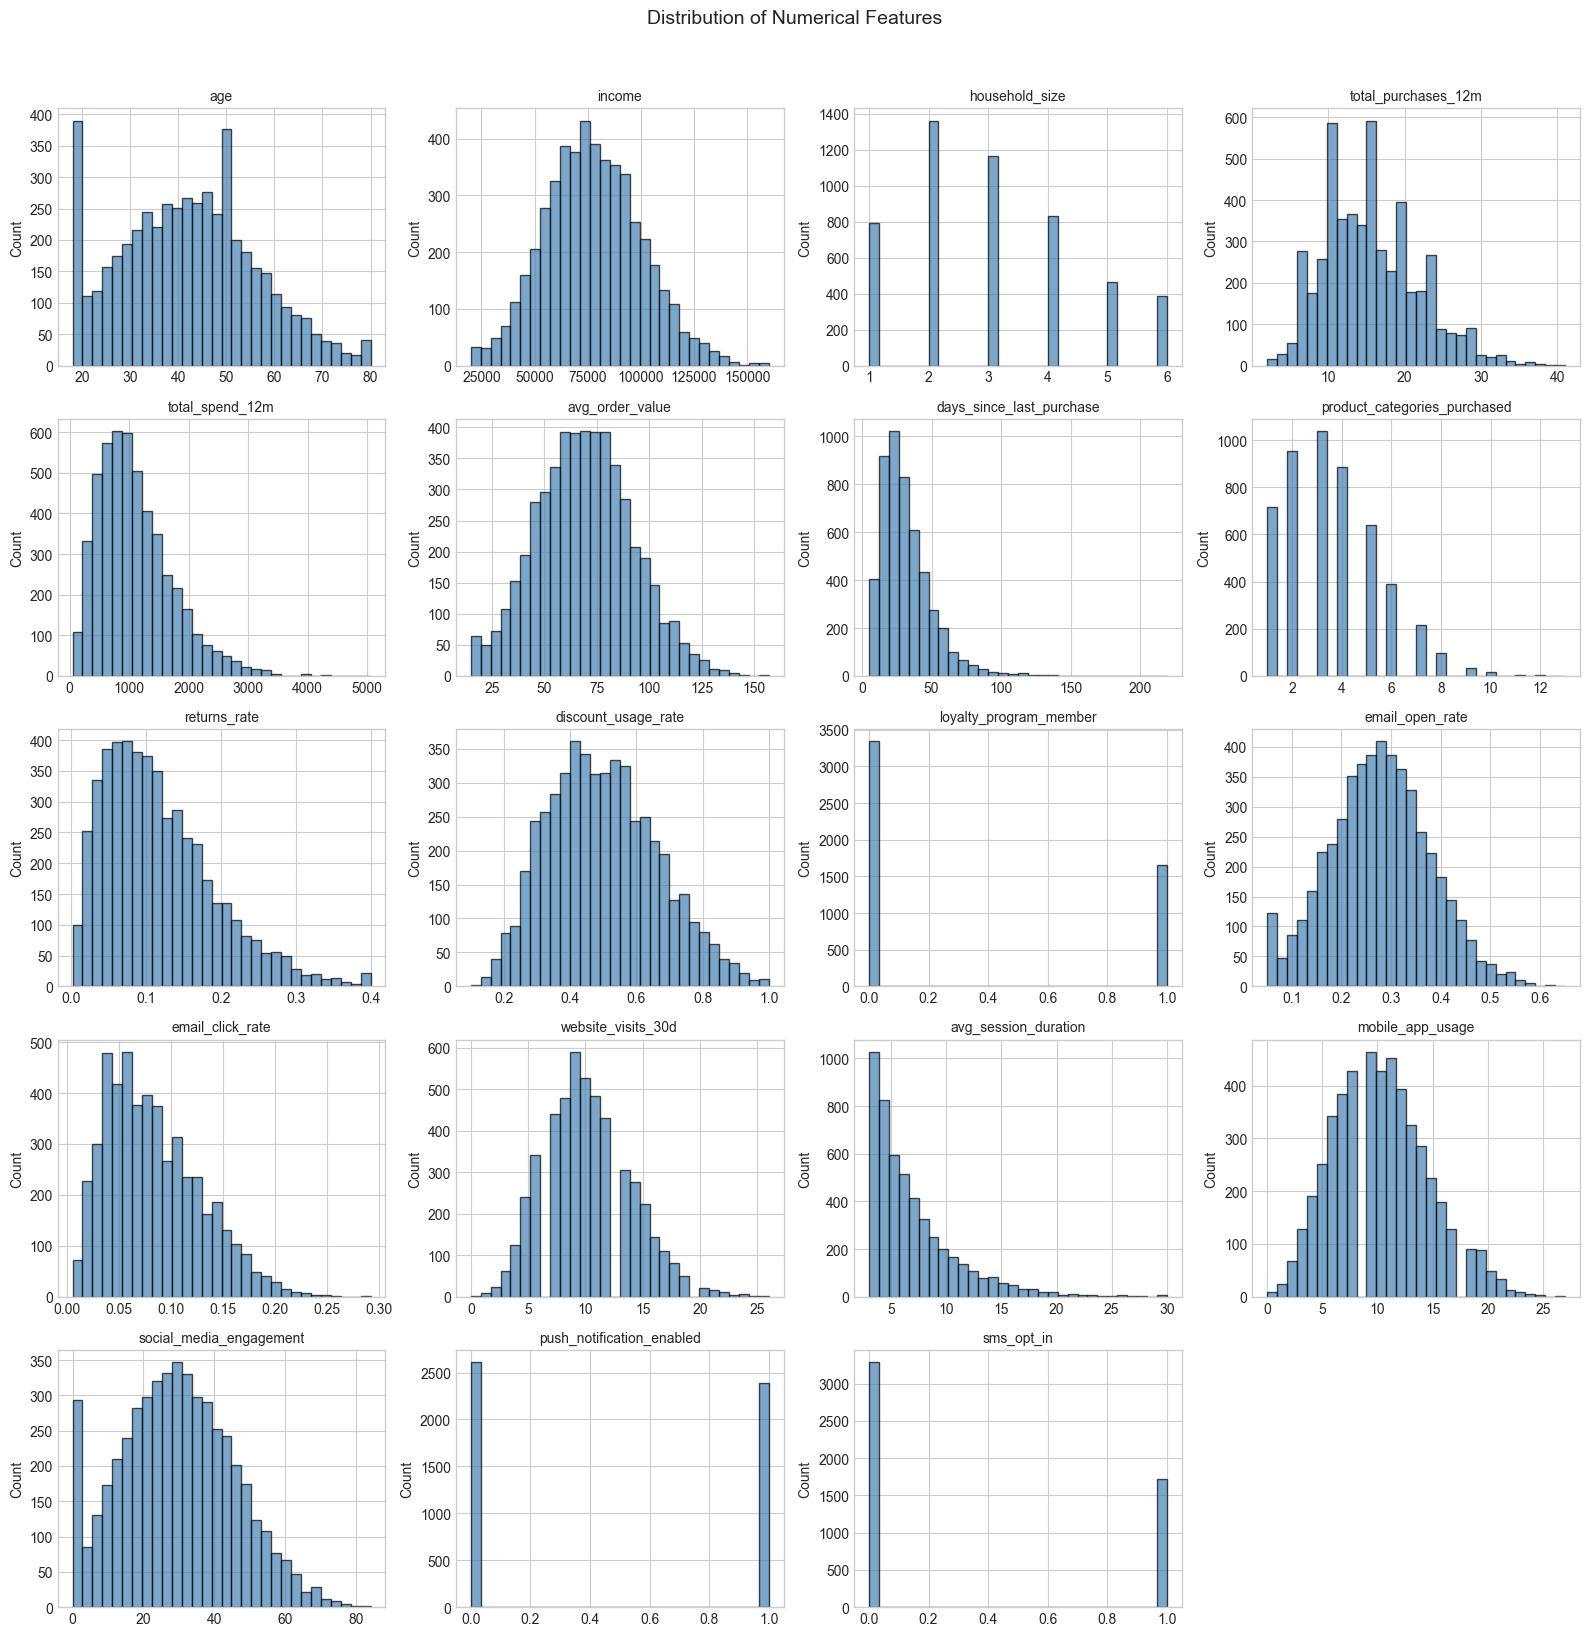

In [6]:
# Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('purchased_product_a')  # Exclude target

# Plot distributions
fig, axes = plt.subplots(5, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Hide empty subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Categorical Feature Distributions

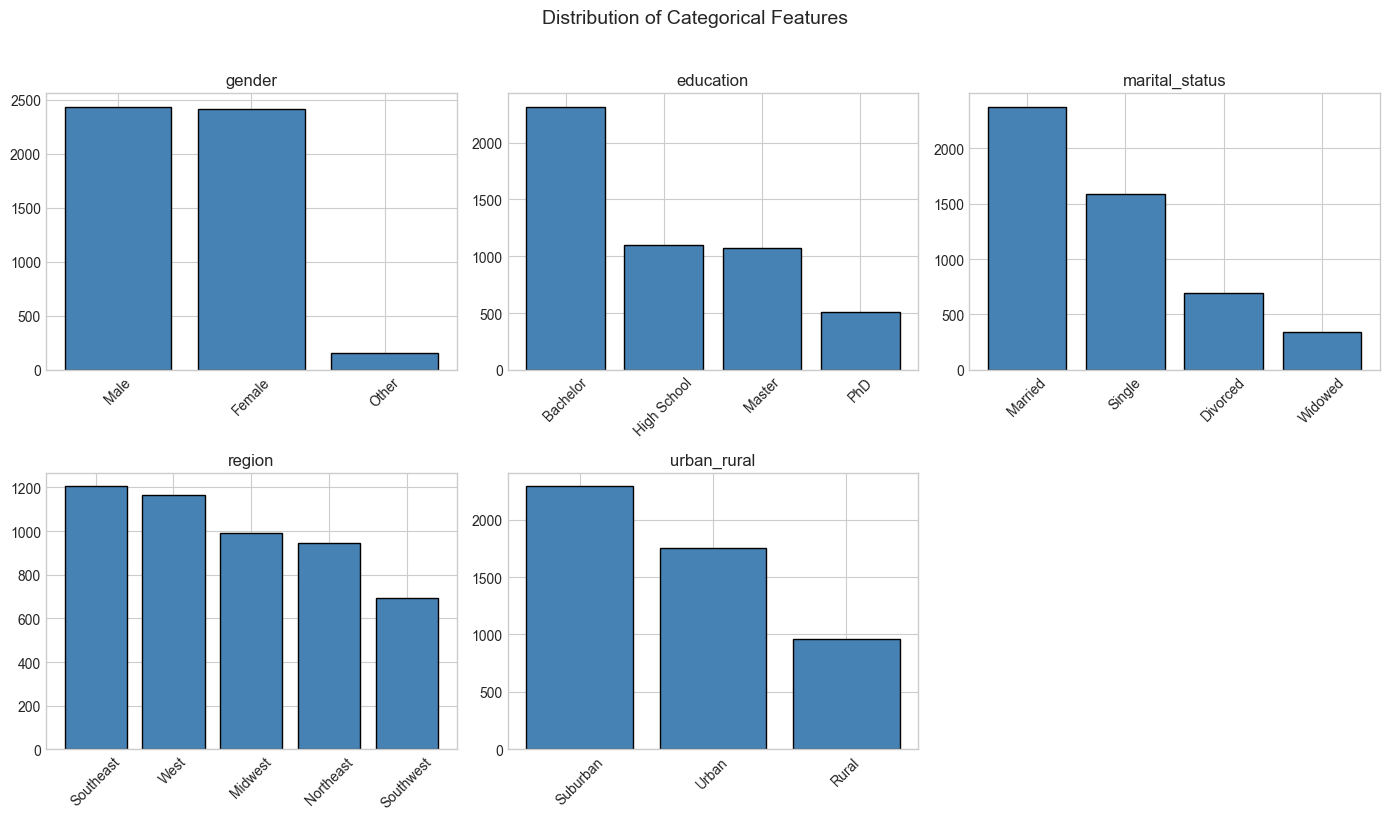

In [7]:
# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values, color='steelblue', edgecolor='black')
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Categorical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap

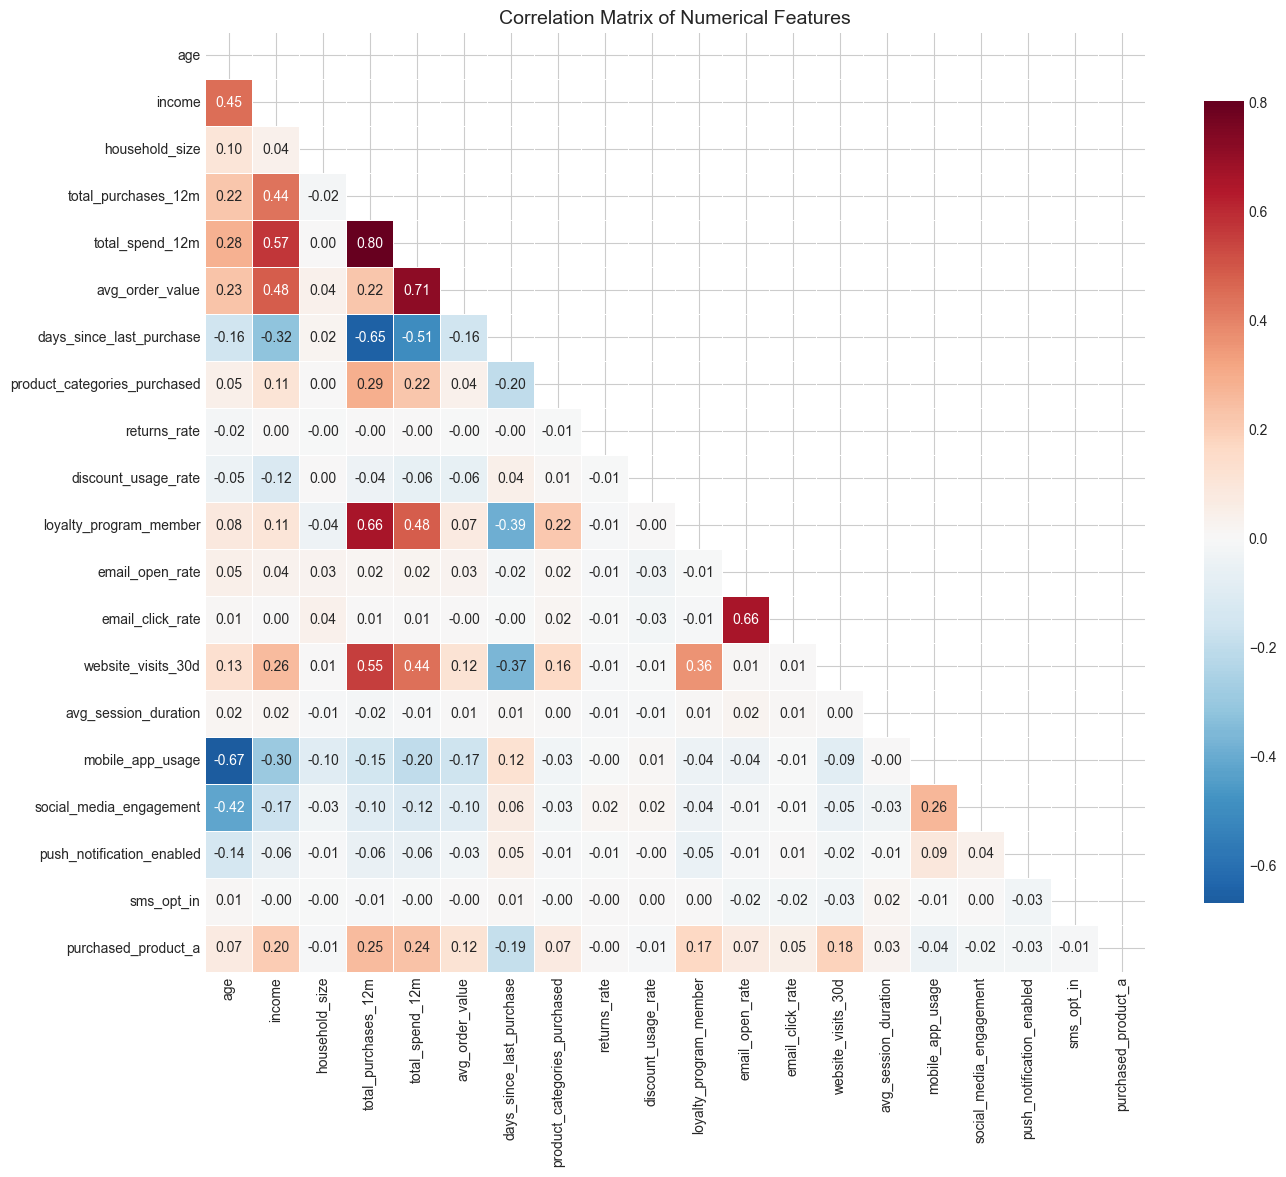

In [8]:
# Correlation matrix for numerical features
plt.figure(figsize=(14, 12))
corr_matrix = df[numerical_cols + ['purchased_product_a']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Target Variable Analysis

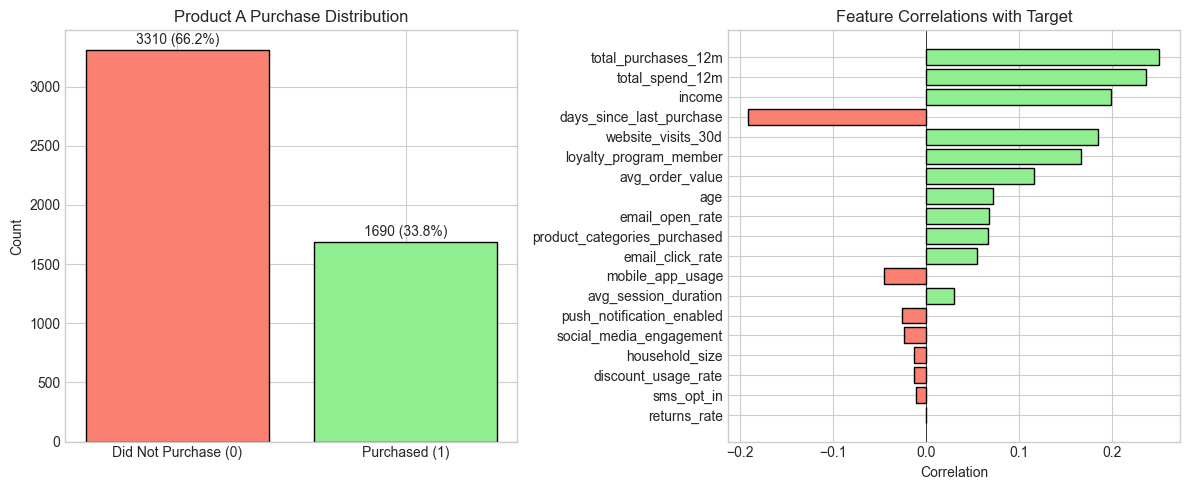

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target distribution
target_counts = df['purchased_product_a'].value_counts()
axes[0].bar(['Did Not Purchase (0)', 'Purchased (1)'], target_counts.values, 
            color=['salmon', 'lightgreen'], edgecolor='black')
axes[0].set_title('Product A Purchase Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f'{v} ({v/len(df)*100:.1f}%)', ha='center')

# Features most correlated with target
target_corr = corr_matrix['purchased_product_a'].drop('purchased_product_a').sort_values(key=abs, ascending=True)
colors = ['salmon' if x < 0 else 'lightgreen' for x in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
axes[1].set_title('Feature Correlations with Target')
axes[1].set_xlabel('Correlation')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

In [10]:
# Separate features and target
X = df.drop('purchased_product_a', axis=1)
y = df['purchased_product_a']

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

Categorical columns (5): ['gender', 'education', 'marital_status', 'region', 'urban_rural']
Numerical columns (19): ['age', 'income', 'household_size', 'total_purchases_12m', 'total_spend_12m', 'avg_order_value', 'days_since_last_purchase', 'product_categories_purchased', 'returns_rate', 'discount_usage_rate', 'loyalty_program_member', 'email_open_rate', 'email_click_rate', 'website_visits_30d', 'avg_session_duration', 'mobile_app_usage', 'social_media_engagement', 'push_notification_enabled', 'sms_opt_in']


In [11]:
# Create a copy for preprocessing
X_processed = X.copy()

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col])
    label_encoders[col] = le
    print(f"{col}: {list(le.classes_)}")

X_processed.head()

gender: ['Female', 'Male', 'Other']
education: ['Bachelor', 'High School', 'Master', 'PhD']
marital_status: ['Divorced', 'Married', 'Single', 'Widowed']
region: ['Midwest', 'Northeast', 'Southeast', 'Southwest', 'West']
urban_rural: ['Rural', 'Suburban', 'Urban']


,age,gender,income,education,marital_status,household_size,region,urban_rural,total_purchases_12m,total_spend_12m,...,discount_usage_rate,loyalty_program_member,email_open_rate,email_click_rate,website_visits_30d,avg_session_duration,mobile_app_usage,social_media_engagement,push_notification_enabled,sms_opt_in
0,49,1,60701,0,1,2,3,2,13,576.94,...,0.501,0,0.236,0.045,11,15.17,6,15.55,1,1
1,39,1,37033,1,1,4,3,1,14,741.65,...,0.436,0,0.338,0.050,8,3.49,13,24.27,0,0
2,51,1,63185,2,3,1,2,1,25,2045.20,...,0.416,1,0.138,0.057,9,5.75,13,44.28,1,0
3,64,1,104063,0,1,4,0,1,10,889.58,...,0.223,0,0.267,0.029,10,5.50,5,10.69,0,0
4,38,1,83414,0,1,1,1,1,22,2071.67,...,0.722,1,0.140,0.042,9,5.68,7,48.87,0,0


In [12]:
# Scale features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_processed.columns)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nScaled data statistics:")
print(f"Mean: {X_scaled.mean():.6f}")
print(f"Std: {X_scaled.std():.6f}")

Scaled data shape: (5000, 24)

Scaled data statistics:
Mean: -0.000000
Std: 1.000000


In [13]:
# Train/test split for supervised learning
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale train/test separately (avoiding data leakage)
scaler_supervised = StandardScaler()
X_train_scaled = scaler_supervised.fit_transform(X_train)
X_test_scaled = scaler_supervised.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTarget distribution in train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Target distribution in test: {y_test.value_counts(normalize=True).round(3).to_dict()}")

Training set: 4000 samples
Test set: 1000 samples

Target distribution in train: {0: 0.662, 1: 0.338}
Target distribution in test: {0: 0.662, 1: 0.338}


---
## 5. Unsupervised Segmentation

### 5.1 K-Means Clustering

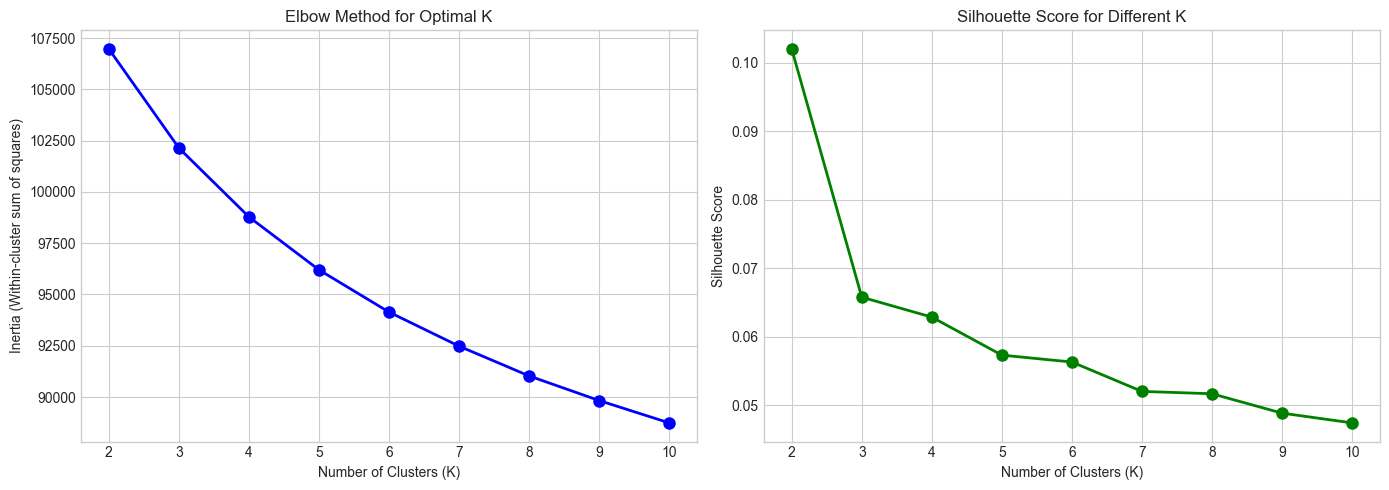


Optimal K based on Silhouette Score: 2
Silhouette scores: {2: 0.102, 3: 0.066, 4: 0.063, 5: 0.057, 6: 0.056, 7: 0.052, 8: 0.052, 9: 0.049, 10: 0.047}


In [14]:
# Find optimal number of clusters using Elbow method and Silhouette score
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].set_xticks(list(K_range))

# Silhouette score
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different K')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

# Best K based on silhouette
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal K based on Silhouette Score: {best_k}")
print(f"Silhouette scores: {dict(zip(K_range, [round(s, 3) for s in silhouette_scores]))}")

In [15]:
# Fit K-Means with optimal K (using 4 clusters for good interpretability)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Add to dataframe
df['kmeans_cluster'] = kmeans_labels

print(f"K-Means with K={optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}")
print(f"\nCluster distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())

K-Means with K=4


Silhouette Score: 0.063

Cluster distribution:
kmeans_cluster
0    1039
1     836
2    1471
3    1654
Name: count, dtype: int64


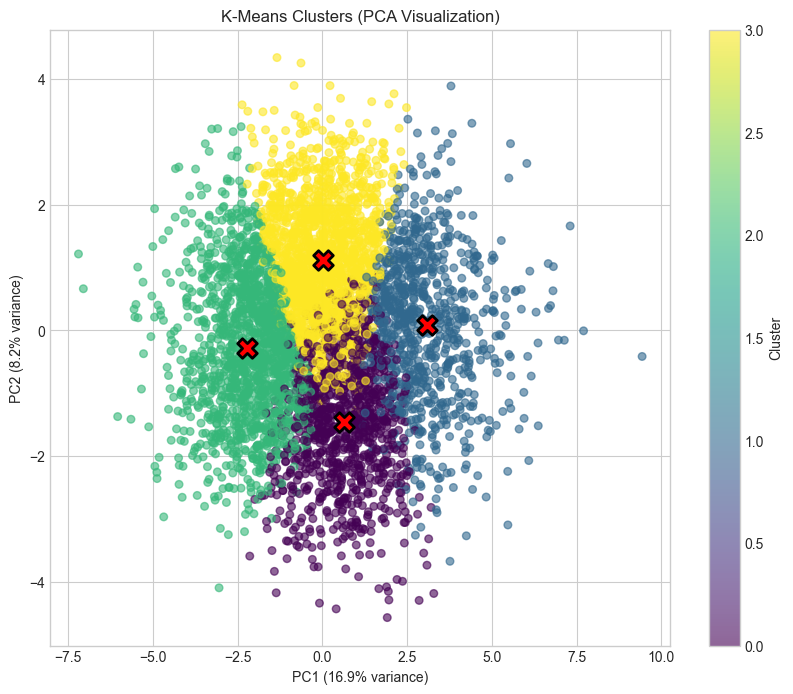

In [16]:
# Visualize clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster')

# Plot cluster centers
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidths=2)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters (PCA Visualization)')
plt.show()

In [17]:
# Cluster profiles
kmeans_profile = df.groupby('kmeans_cluster').agg({
    'age': 'mean',
    'income': 'mean',
    'total_purchases_12m': 'mean',
    'total_spend_12m': 'mean',
    'days_since_last_purchase': 'mean',
    'email_open_rate': 'mean',
    'website_visits_30d': 'mean',
    'loyalty_program_member': 'mean',
    'purchased_product_a': ['mean', 'count']
}).round(2)

kmeans_profile.columns = ['Avg Age', 'Avg Income', 'Avg Purchases', 'Avg Spend', 
                          'Avg Days Since Purchase', 'Email Open Rate', 'Website Visits',
                          'Loyalty %', 'Product A Purchase Rate', 'Count']
kmeans_profile

,Avg Age,Avg Income,Avg Purchases,Avg Spend,Avg Days Since Purchase,Email Open Rate,Website Visits,Loyalty %,Product A Purchase Rate,Count
kmeans_cluster,,,,,,,,,,
0,35.77,71224.78,19.87,1244.10,21.90,0.27,11.91,0.87,0.41,1039
1,53.24,102784.35,23.23,2071.51,18.96,0.29,13.21,0.75,0.54,836
2,31.94,60306.96,10.06,567.91,46.34,0.26,8.09,0.03,0.20,1471
3,48.99,84096.84,13.68,1004.16,31.40,0.30,9.48,0.05,0.31,1654


### 5.2 Hierarchical Clustering

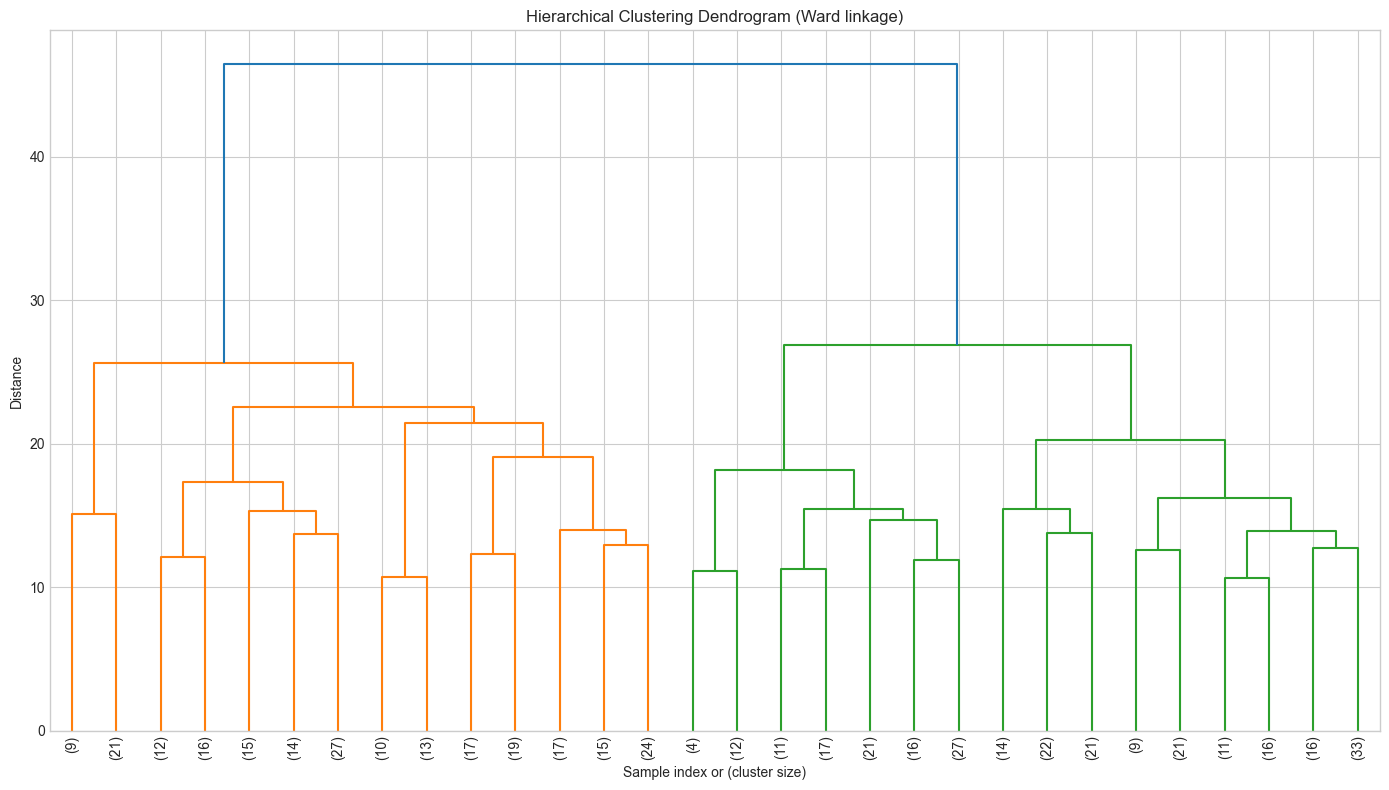

In [18]:
# Create dendrogram (using sample for visualization)
sample_size = 500
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage
linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 8))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [19]:
# Fit Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = agg_clustering.fit_predict(X_scaled)

df['hierarchical_cluster'] = hierarchical_labels

print(f"Hierarchical Clustering with 4 clusters")
print(f"Silhouette Score: {silhouette_score(X_scaled, hierarchical_labels):.3f}")
print(f"\nCluster distribution:")
print(df['hierarchical_cluster'].value_counts().sort_index())

Hierarchical Clustering with 4 clusters


Silhouette Score: 0.031

Cluster distribution:
hierarchical_cluster
0    2382
1     723
2     982
3     913
Name: count, dtype: int64


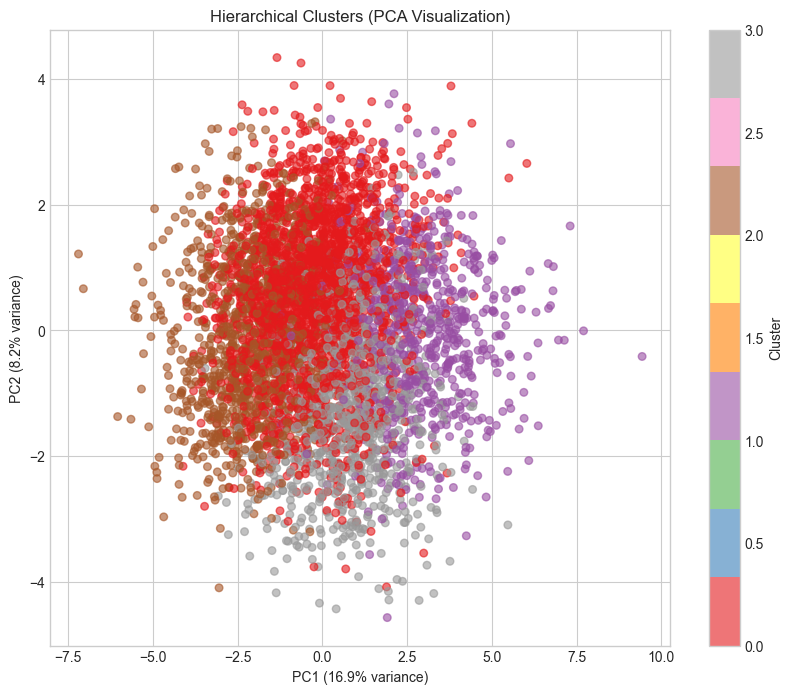

In [20]:
# Visualize hierarchical clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap='Set1', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Hierarchical Clusters (PCA Visualization)')
plt.show()

### 5.3 DBSCAN Clustering

In [21]:
# DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN Results:")
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Noise points: {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"\nCluster distribution:")
print(df['dbscan_cluster'].value_counts().sort_index())

# Silhouette score (excluding noise)
if n_clusters_dbscan > 1:
    mask = dbscan_labels != -1
    print(f"\nSilhouette Score (excluding noise): {silhouette_score(X_scaled[mask], dbscan_labels[mask]):.3f}")

DBSCAN Results:
Number of clusters: 0
Noise points: 5000 (100.0%)

Cluster distribution:
dbscan_cluster
-1    5000
Name: count, dtype: int64


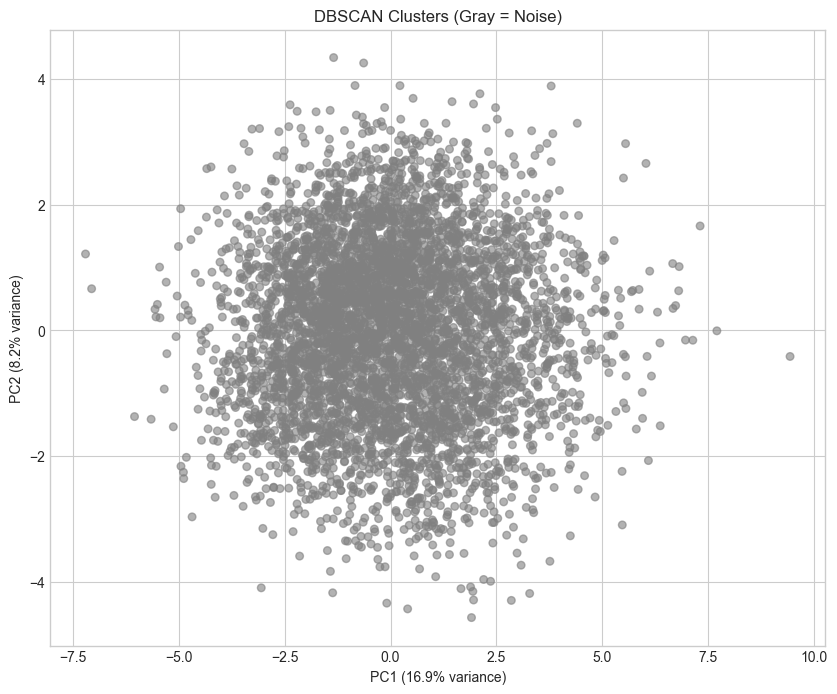

In [22]:
# Visualize DBSCAN clusters
plt.figure(figsize=(10, 8))
colors = ['gray' if x == -1 else plt.cm.Set2(x) for x in dbscan_labels]
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=30)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('DBSCAN Clusters (Gray = Noise)')
plt.show()

### 5.4 Gaussian Mixture Model (GMM)

In [23]:
# GMM with 4 components
gmm = GaussianMixture(n_components=4, random_state=RANDOM_STATE, n_init=5)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)

df['gmm_cluster'] = gmm_labels

print(f"GMM with 4 components")
print(f"Silhouette Score: {silhouette_score(X_scaled, gmm_labels):.3f}")
print(f"BIC: {gmm.bic(X_scaled):.2f}")
print(f"AIC: {gmm.aic(X_scaled):.2f}")
print(f"\nCluster distribution:")
print(df['gmm_cluster'].value_counts().sort_index())

GMM with 4 components
Silhouette Score: 0.048
BIC: 237414.24
AIC: 228948.40

Cluster distribution:
gmm_cluster
0    1444
1    1881
2      45
3    1630
Name: count, dtype: int64


In [24]:
# GMM provides soft assignments (probabilities)
print("Example: Cluster probabilities for first 5 customers")
probs_df = pd.DataFrame(gmm_probs[:5], columns=[f'Cluster {i}' for i in range(4)])
probs_df['Assigned'] = gmm_labels[:5]
probs_df.round(3)

Example: Cluster probabilities for first 5 customers


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Assigned
0,0.751,0.249,0.0,0.0,0
1,0.529,0.471,0.0,0.0,0
2,0.000,0.000,0.0,1.0,3
3,0.582,0.418,0.0,0.0,0
4,0.000,0.000,0.0,1.0,3


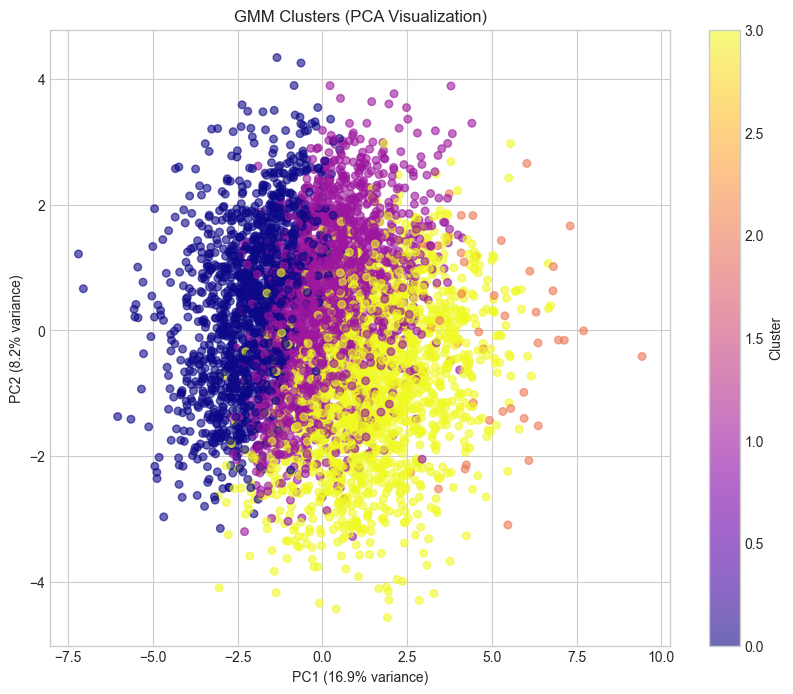

In [25]:
# Visualize GMM clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='plasma', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('GMM Clusters (PCA Visualization)')
plt.show()

### 5.5 RFM Segmentation

RFM (Recency, Frequency, Monetary) is a business-oriented segmentation method.

In [26]:
# Calculate RFM scores
rfm_data = df[['days_since_last_purchase', 'total_purchases_12m', 'total_spend_12m']].copy()
rfm_data.columns = ['Recency', 'Frequency', 'Monetary']

# Create RFM scores (1-5 quintiles)
# Note: For Recency, lower is better
rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Convert to numeric
rfm_data['R_Score'] = rfm_data['R_Score'].astype(int)
rfm_data['F_Score'] = rfm_data['F_Score'].astype(int)
rfm_data['M_Score'] = rfm_data['M_Score'].astype(int)

# Calculate RFM combined score
rfm_data['RFM_Score'] = rfm_data['R_Score'] + rfm_data['F_Score'] + rfm_data['M_Score']

rfm_data.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,18,13,576.94,4,2,2,8
1,25,14,741.65,3,3,2,8
2,24,25,2045.20,4,5,5,14
3,28,10,889.58,3,1,3,7
4,21,22,2071.67,4,5,5,14
5,28,14,486.22,3,3,1,7
6,34,15,1083.71,2,3,3,8
7,32,16,1475.74,3,3,4,10
8,38,12,467.93,2,2,1,5
9,29,23,657.74,3,5,2,10


In [27]:
# Create RFM segments
def rfm_segment(row):
    if row['RFM_Score'] >= 12:
        return 'Champions'
    elif row['RFM_Score'] >= 9:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 6:
        return 'Potential Loyalists'
    elif row['RFM_Score'] >= 4:
        return 'At Risk'
    else:
        return 'Hibernating'

rfm_data['RFM_Segment'] = rfm_data.apply(rfm_segment, axis=1)
df['rfm_segment'] = rfm_data['RFM_Segment']

print("RFM Segment Distribution:")
print(rfm_data['RFM_Segment'].value_counts())

RFM Segment Distribution:
RFM_Segment
Champions              1518
Loyal Customers        1264
Potential Loyalists    1094
At Risk                 698
Hibernating             426
Name: count, dtype: int64


In [28]:
# RFM segment profiles
rfm_profile = pd.concat([rfm_data, df[['purchased_product_a', 'income', 'age']]], axis=1)
rfm_summary = rfm_profile.groupby('RFM_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RFM_Score': 'mean',
    'income': 'mean',
    'age': 'mean',
    'purchased_product_a': ['mean', 'count']
}).round(2)

rfm_summary.columns = ['Avg Recency', 'Avg Frequency', 'Avg Monetary', 'Avg RFM Score', 
                       'Avg Income', 'Avg Age', 'Product A Rate', 'Count']
rfm_summary.sort_values('Product A Rate', ascending=False)

,Avg Recency,Avg Frequency,Avg Monetary,Avg RFM Score,Avg Income,Avg Age,Product A Rate,Count
RFM_Segment,,,,,,,,
Champions,17.67,22.43,1788.70,13.45,90379.62,45.88,0.49,1518
Loyal Customers,25.63,15.95,1106.50,10.01,79766.00,42.58,0.36,1264
Potential Loyalists,33.95,12.49,790.00,7.07,73363.10,40.83,0.27,1094
At Risk,46.23,9.56,562.53,4.52,64995.43,38.13,0.18,698
Hibernating,70.62,6.97,351.89,3.00,56552.70,35.08,0.15,426


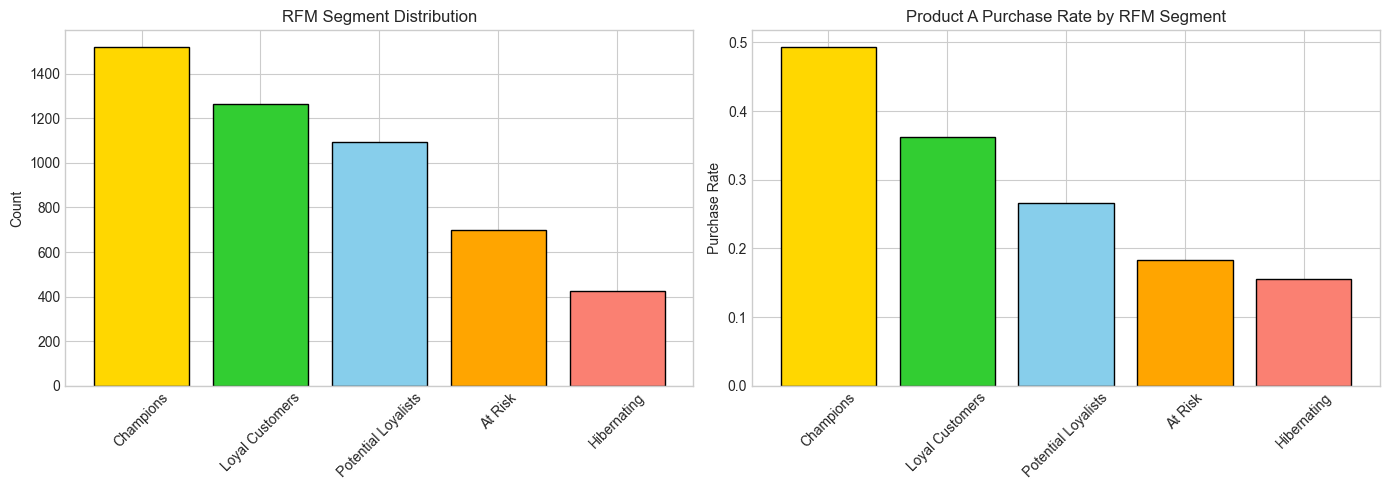

In [29]:
# Visualize RFM segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment distribution
segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Hibernating']
colors = ['gold', 'limegreen', 'skyblue', 'orange', 'salmon']
segment_counts = df['rfm_segment'].value_counts()[segment_order]
axes[0].bar(segment_order, segment_counts.values, color=colors, edgecolor='black')
axes[0].set_title('RFM Segment Distribution')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count')

# Purchase rate by segment
purchase_rates = df.groupby('rfm_segment')['purchased_product_a'].mean()[segment_order]
axes[1].bar(segment_order, purchase_rates.values, color=colors, edgecolor='black')
axes[1].set_title('Product A Purchase Rate by RFM Segment')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Purchase Rate')

plt.tight_layout()
plt.show()

---
## 6. Supervised Learning

### 6.1 Logistic Regression

In [30]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.3f}")

Logistic Regression Results:
Accuracy: 0.698
Precision: 0.629
Recall: 0.260
F1-Score: 0.368
AUC-ROC: 0.669


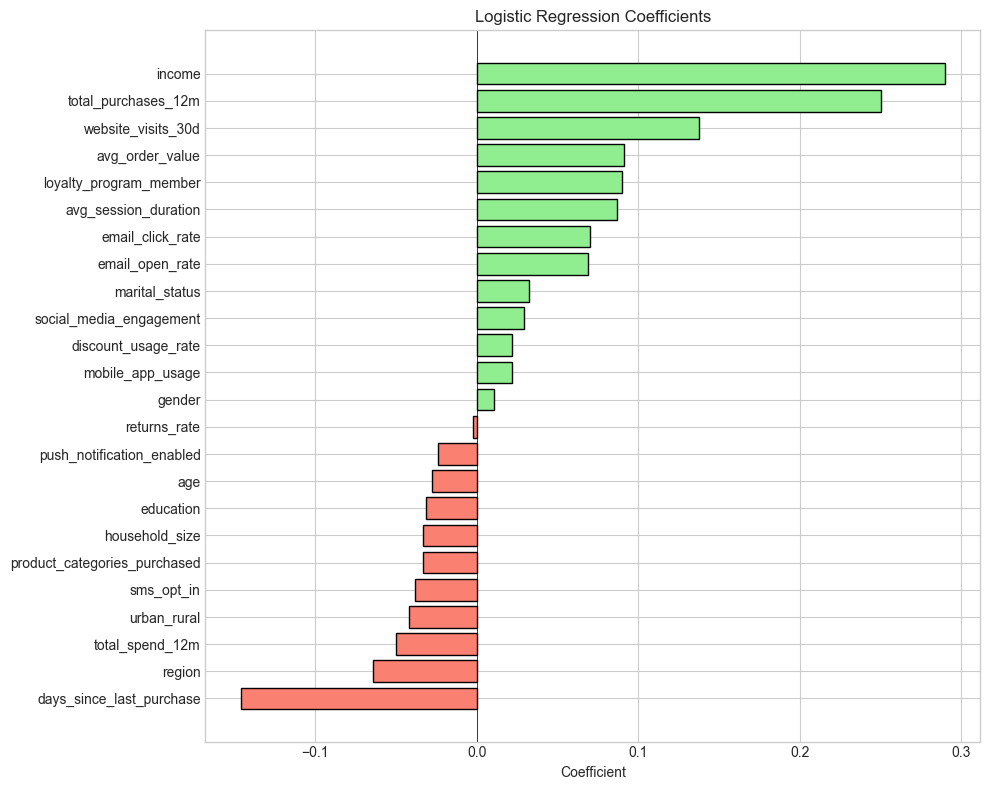

In [31]:
# Feature coefficients
feature_names = X_processed.columns.tolist()
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'lightgreen' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.xlabel('Coefficient')
plt.title('Logistic Regression Coefficients')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 6.2 Decision Tree

In [32]:
# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)  # Using unscaled data for interpretability

# Predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_dt):.3f}")

Decision Tree Results:
Accuracy: 0.676
Precision: 0.559
Recall: 0.195
F1-Score: 0.289
AUC-ROC: 0.655


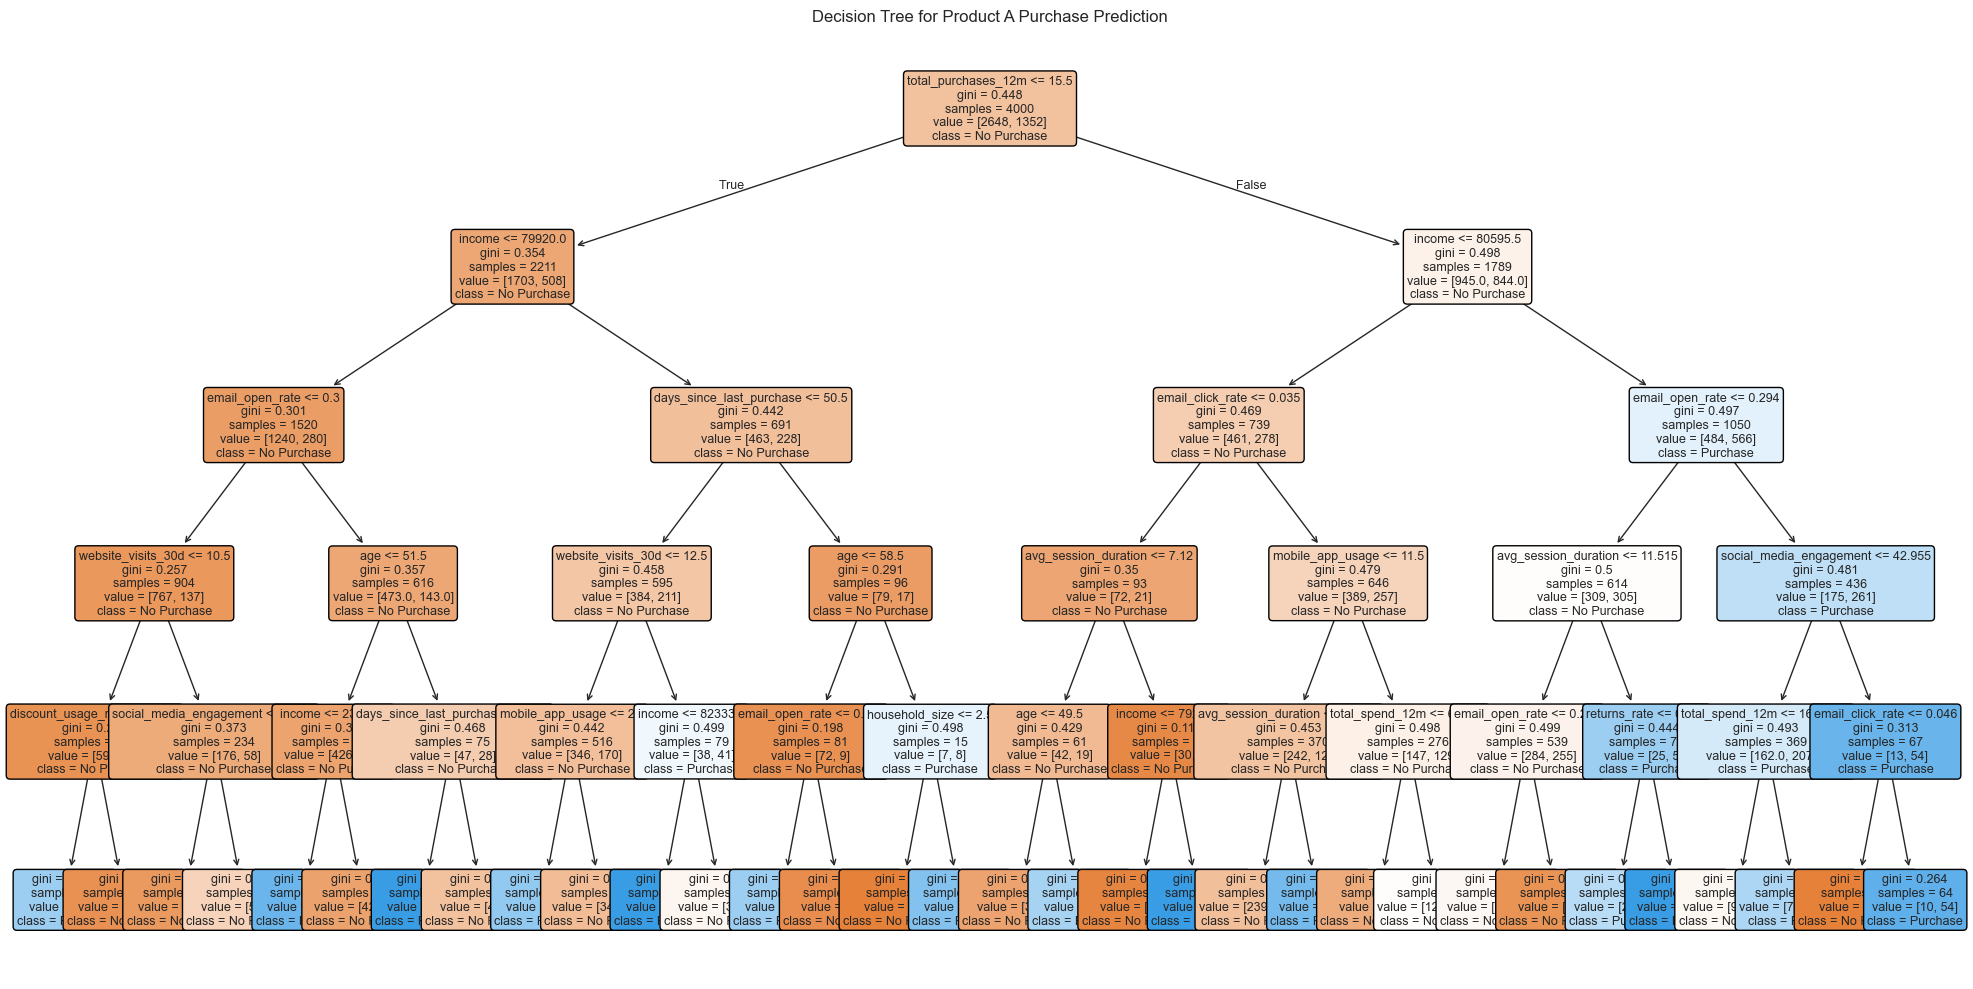

In [33]:
# Visualize Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=feature_names, class_names=['No Purchase', 'Purchase'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree for Product A Purchase Prediction')
plt.tight_layout()
plt.show()

### 6.3 Random Forest

In [34]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.3f}")

Random Forest Results:
Accuracy: 0.686
Precision: 0.571
Recall: 0.287
F1-Score: 0.382
AUC-ROC: 0.683


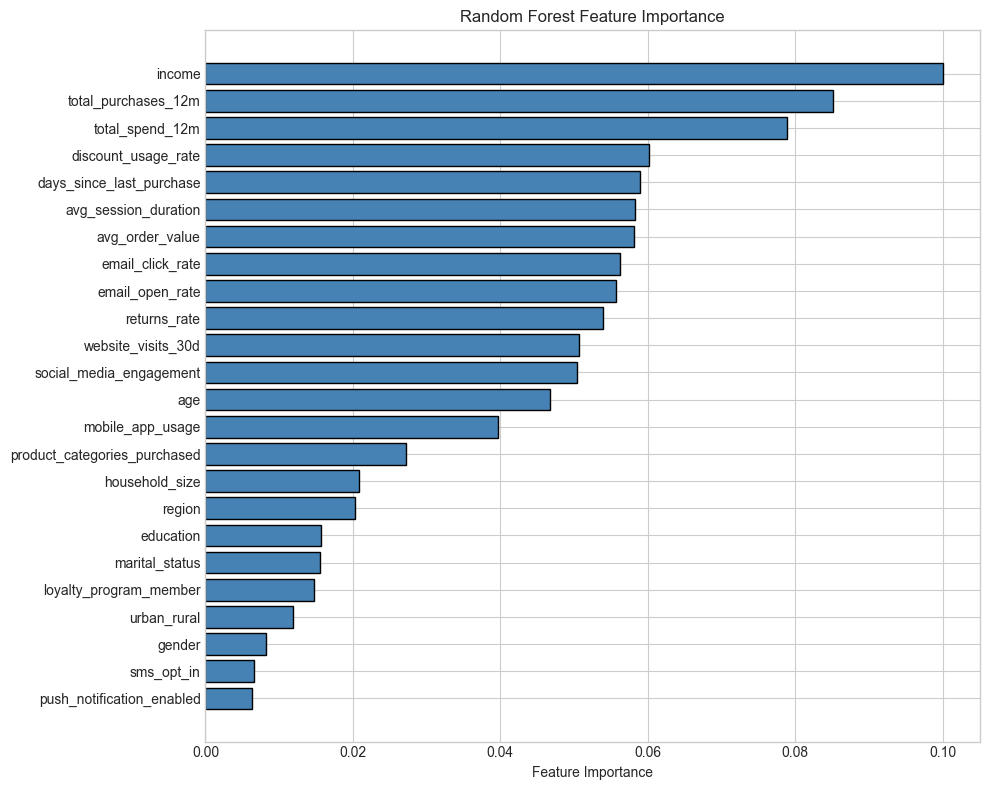

In [35]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### 6.4 Gradient Boosting with SHAP

In [36]:
# Train Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)

# Predictions
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gb):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_gb):.3f}")

Gradient Boosting Results:
Accuracy: 0.679
Precision: 0.542
Recall: 0.322
F1-Score: 0.404
AUC-ROC: 0.667


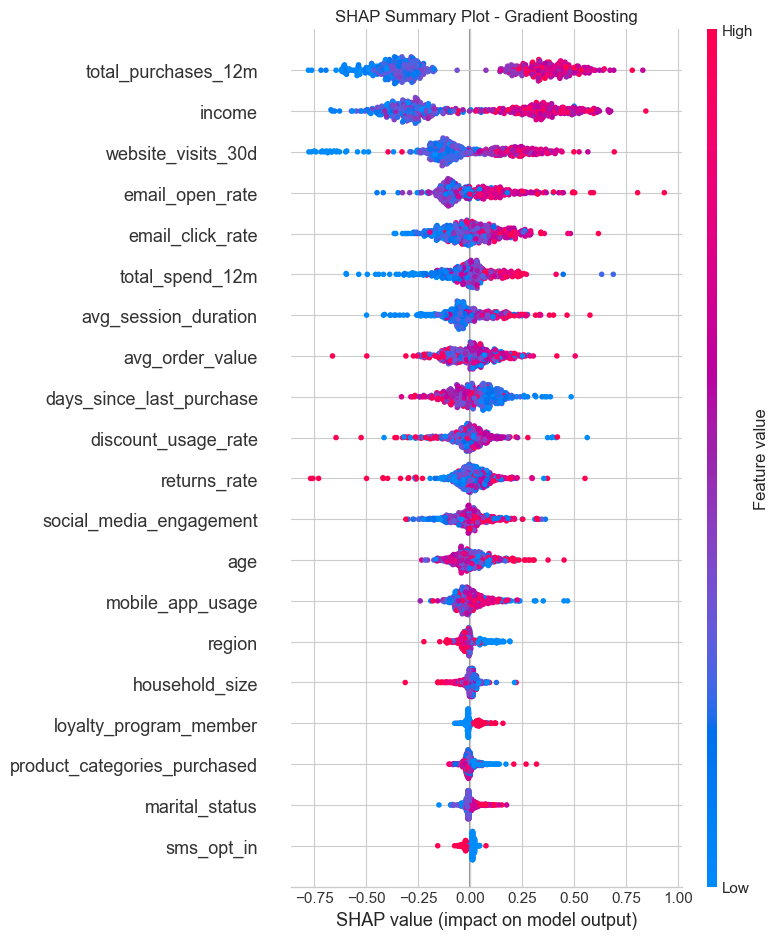

In [37]:
# SHAP analysis
if SHAP_AVAILABLE:
    # Create SHAP explainer
    explainer = shap.TreeExplainer(gb)
    
    # Calculate SHAP values for test set (sample for speed)
    X_test_sample = X_test.iloc[:500]
    shap_values = explainer.shap_values(X_test_sample)
    
    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
    plt.title('SHAP Summary Plot - Gradient Boosting')
    plt.tight_layout()
    plt.show()
else:
    print("SHAP not available. Skipping SHAP analysis.")

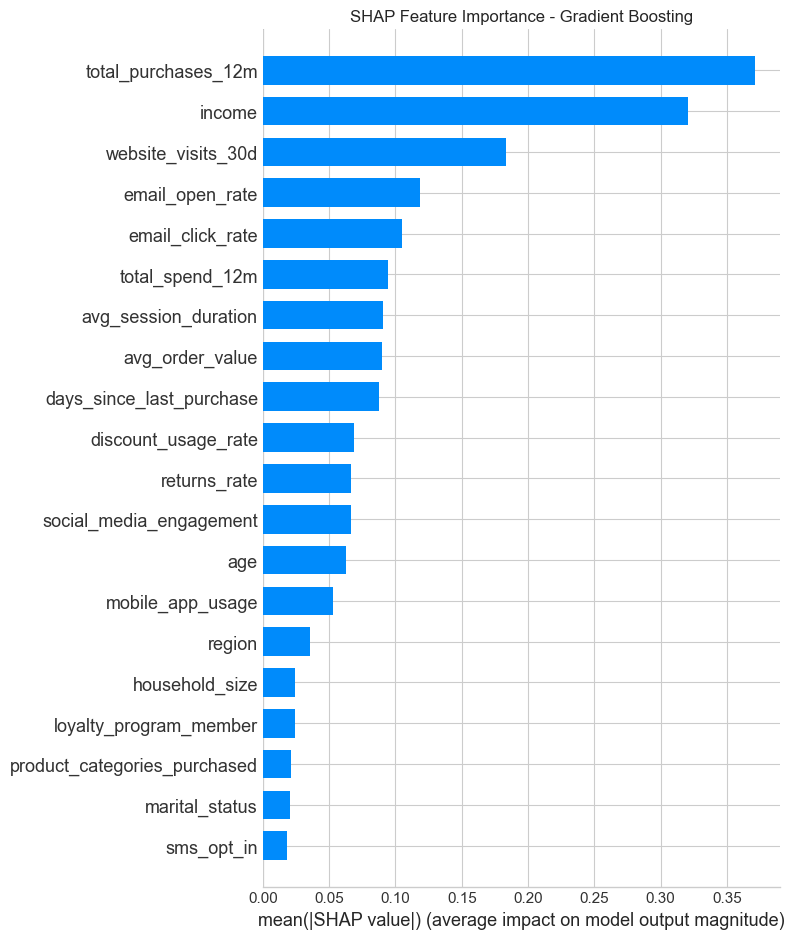

In [38]:
# SHAP bar plot (feature importance based on SHAP)
if SHAP_AVAILABLE:
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, plot_type='bar', show=False)
    plt.title('SHAP Feature Importance - Gradient Boosting')
    plt.tight_layout()
    plt.show()

---
## 7. Model Comparison

In [39]:
# Compare supervised models
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
}).round(3)

model_results.set_index('Model', inplace=True)
model_results

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.698,0.629,0.260,0.368,0.669
Decision Tree,0.676,0.559,0.195,0.289,0.655
Random Forest,0.686,0.571,0.287,0.382,0.683
Gradient Boosting,0.679,0.542,0.322,0.404,0.667


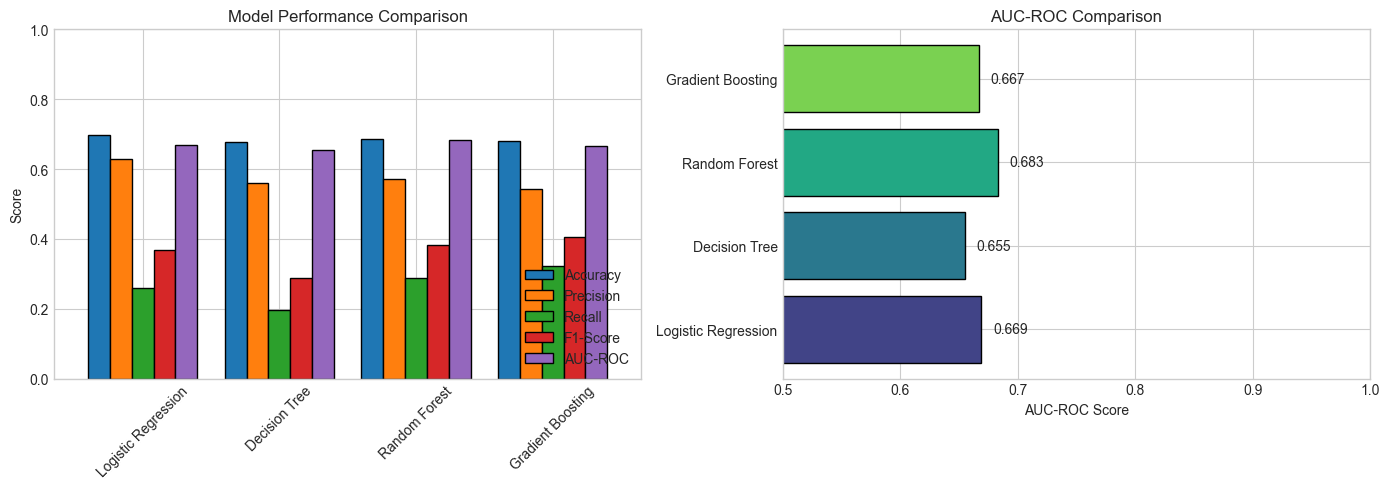

In [40]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of metrics
model_results.plot(kind='bar', ax=axes[0], width=0.8, edgecolor='black')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xlabel('')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='lower right')

# AUC-ROC comparison
model_names = model_results.index.tolist()
auc_scores = model_results['AUC-ROC'].values
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(model_names)))
bars = axes[1].barh(model_names, auc_scores, color=colors, edgecolor='black')
axes[1].set_title('AUC-ROC Comparison')
axes[1].set_xlabel('AUC-ROC Score')
axes[1].set_xlim(0.5, 1)

for bar, score in zip(bars, auc_scores):
    axes[1].text(score + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.3f}', va='center')

plt.tight_layout()
plt.show()

---
## 8. Segment Profiling & Comparison

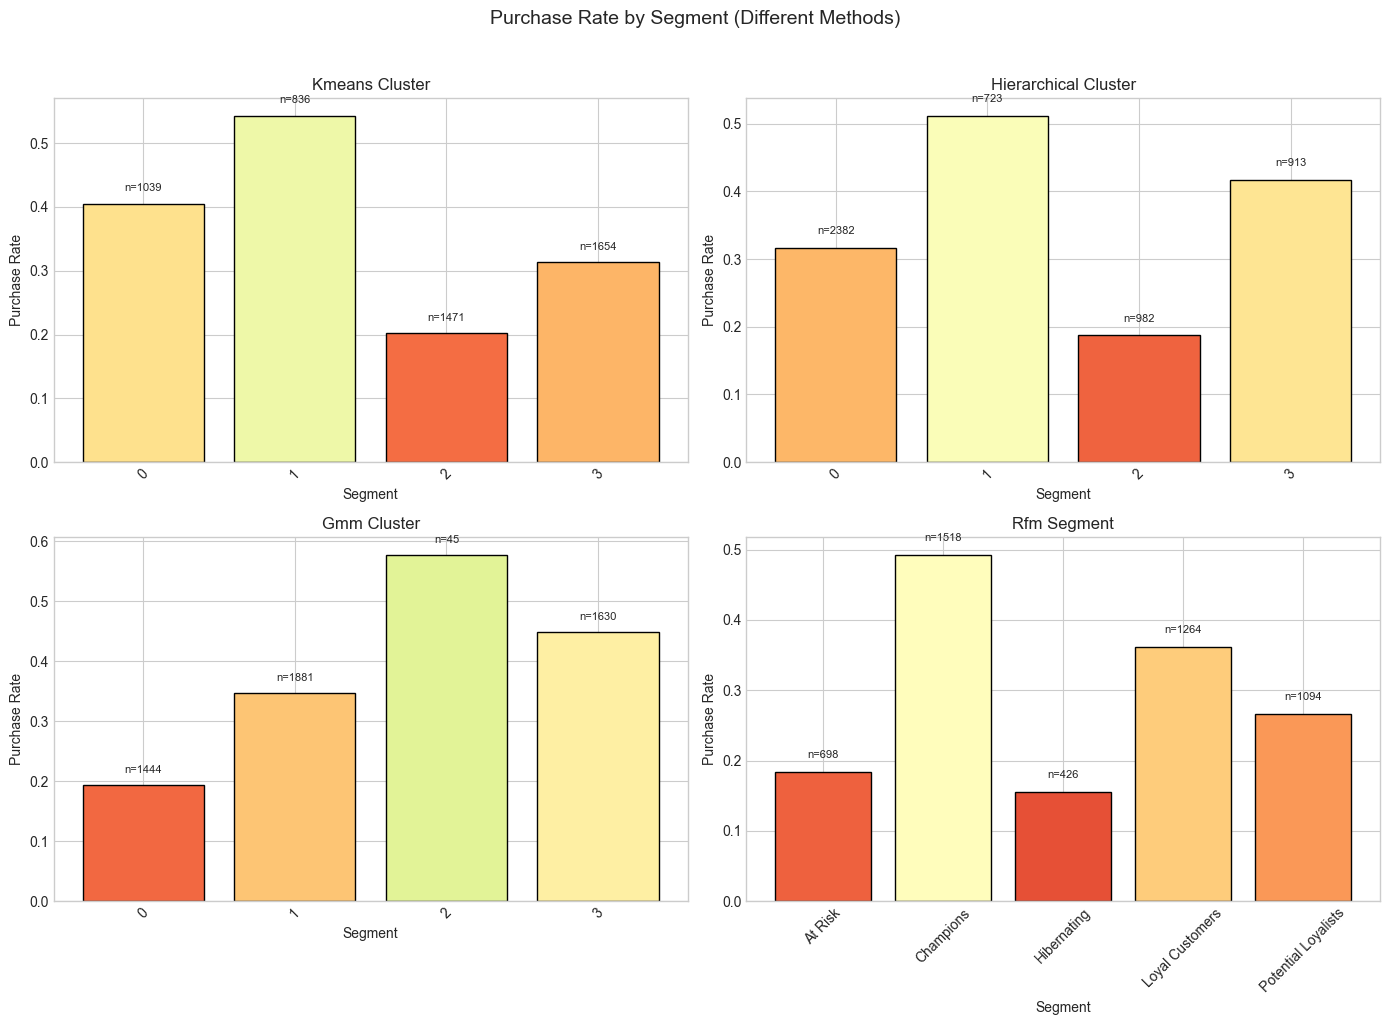

In [41]:
# Compare clustering methods by purchase rate
clustering_methods = ['kmeans_cluster', 'hierarchical_cluster', 'gmm_cluster', 'rfm_segment']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, method in enumerate(clustering_methods):
    purchase_by_cluster = df.groupby(method)['purchased_product_a'].agg(['mean', 'count'])
    purchase_by_cluster.columns = ['Purchase Rate', 'Count']
    
    colors = plt.cm.RdYlGn(purchase_by_cluster['Purchase Rate'])
    bars = axes[i].bar(purchase_by_cluster.index.astype(str), purchase_by_cluster['Purchase Rate'], 
                       color=colors, edgecolor='black')
    axes[i].set_title(f'{method.replace("_", " ").title()}')
    axes[i].set_xlabel('Segment')
    axes[i].set_ylabel('Purchase Rate')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add count labels
    for bar, count in zip(bars, purchase_by_cluster['Count']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                     f'n={count}', ha='center', fontsize=8)

plt.suptitle('Purchase Rate by Segment (Different Methods)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# Propensity-based segmentation using best model
# Use all data for final propensity scores
df['purchase_propensity'] = gb.predict_proba(X_processed)[:, 1]

# Create propensity segments
df['propensity_segment'] = pd.cut(df['purchase_propensity'], 
                                   bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                                   labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

propensity_profile = df.groupby('propensity_segment').agg({
    'age': 'mean',
    'income': 'mean',
    'total_purchases_12m': 'mean',
    'total_spend_12m': 'mean',
    'email_open_rate': 'mean',
    'website_visits_30d': 'mean',
    'purchased_product_a': ['mean', 'count'],
    'purchase_propensity': 'mean'
}).round(2)

propensity_profile.columns = ['Avg Age', 'Avg Income', 'Avg Purchases', 'Avg Spend',
                               'Email Open Rate', 'Website Visits', 'Actual Purchase Rate', 
                               'Count', 'Avg Propensity']
propensity_profile

,Avg Age,Avg Income,Avg Purchases,Avg Spend,Email Open Rate,Website Visits,Actual Purchase Rate,Count,Avg Propensity
propensity_segment,,,,,,,,,
Very Low,38.84,64761.51,11.37,722.27,0.26,8.35,0.04,1714,0.13
Low,42.32,79916.10,15.99,1135.38,0.28,10.48,0.19,1590,0.29
Medium,43.30,84583.39,18.04,1292.98,0.28,11.29,0.63,908,0.49
High,45.71,91326.92,20.26,1602.25,0.30,12.27,0.94,678,0.69
Very High,50.11,99534.33,22.52,1973.67,0.31,13.35,0.98,110,0.84


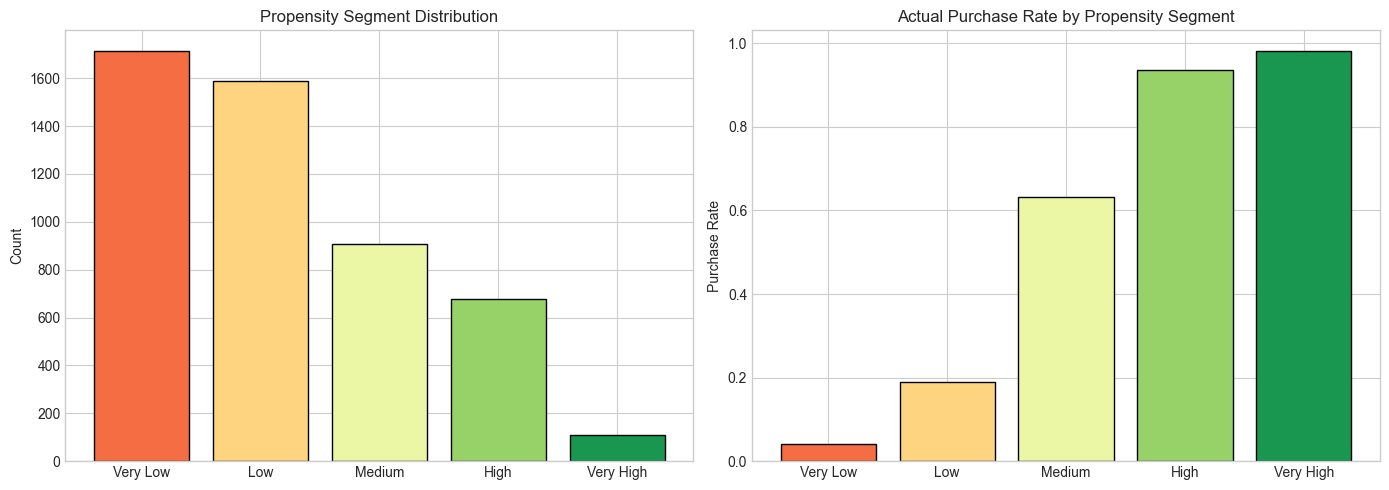

In [43]:
# Visualize propensity segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
segment_counts = df['propensity_segment'].value_counts().reindex(['Very Low', 'Low', 'Medium', 'High', 'Very High'])
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 5))
axes[0].bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Propensity Segment Distribution')
axes[0].set_ylabel('Count')

# Actual vs Predicted
actual_rates = df.groupby('propensity_segment')['purchased_product_a'].mean()
actual_rates = actual_rates.reindex(['Very Low', 'Low', 'Medium', 'High', 'Very High'])
axes[1].bar(actual_rates.index, actual_rates.values, color=colors, edgecolor='black')
axes[1].set_title('Actual Purchase Rate by Propensity Segment')
axes[1].set_ylabel('Purchase Rate')

plt.tight_layout()
plt.show()

---
## 8.5 Combined Method: RFM + Propensity Matrix

This hybrid approach combines the business intuition of RFM segmentation with the predictive power of machine learning propensity scores to create actionable marketing segments.

In [44]:
# === COMBINED METHOD 1: RFM + Propensity Matrix ===
# Create a 2D segmentation combining RFM value with ML propensity

# Simplify RFM into 3 tiers for the matrix
def rfm_tier(segment):
    if segment in ['Champions', 'Loyal Customers']:
        return 'High Value'
    elif segment in ['Potential Loyalists']:
        return 'Medium Value'
    else:
        return 'Low Value'

df['rfm_tier'] = df['rfm_segment'].apply(rfm_tier)

# Simplify propensity into 3 tiers
def propensity_tier(segment):
    if segment in ['Very High', 'High']:
        return 'High Propensity'
    elif segment == 'Medium':
        return 'Medium Propensity'
    else:
        return 'Low Propensity'

df['propensity_tier'] = df['propensity_segment'].apply(propensity_tier)

# Create combined segment
df['combined_segment'] = df['rfm_tier'] + ' / ' + df['propensity_tier']

# View the matrix
combined_matrix = pd.crosstab(df['rfm_tier'], df['propensity_tier'], margins=True)
print("RFM vs Propensity Matrix (Customer Counts):")
print(combined_matrix)
print()

# Purchase rate by combined segment
combined_stats = df.groupby('combined_segment').agg({
    'purchased_product_a': ['mean', 'count'],
    'income': 'mean',
    'total_spend_12m': 'mean'
}).round(3)
combined_stats.columns = ['Purchase Rate', 'Count', 'Avg Income', 'Avg Spend']
combined_stats = combined_stats.sort_values('Purchase Rate', ascending=False)
print("Combined Segment Performance:")
combined_stats

RFM vs Propensity Matrix (Customer Counts):
propensity_tier  High Propensity  Low Propensity  Medium Propensity   All
rfm_tier                                                                 
High Value                   698            1371                713  2782
Low Value                     33            1019                 72  1124
Medium Value                  57             914                123  1094
All                          788            3304                908  5000

Combined Segment Performance:


,Purchase Rate,Count,Avg Income,Avg Spend
combined_segment,,,,
Medium Value / High Propensity,0.982,57,79068.632,841.511
Low Value / High Propensity,0.970,33,56650.758,448.357
High Value / High Propensity,0.938,698,95260.807,1777.461
Low Value / Medium Propensity,0.931,72,63330.083,499.814
Medium Value / Medium Propensity,0.821,123,79525.813,827.413
High Value / Medium Propensity,0.571,713,87602.074,1453.389
Medium Value / Low Propensity,0.147,914,72177.943,781.749
High Value / Low Propensity,0.104,1371,79553.731,1339.850
Low Value / Low Propensity,0.093,1019,61853.797,482.599


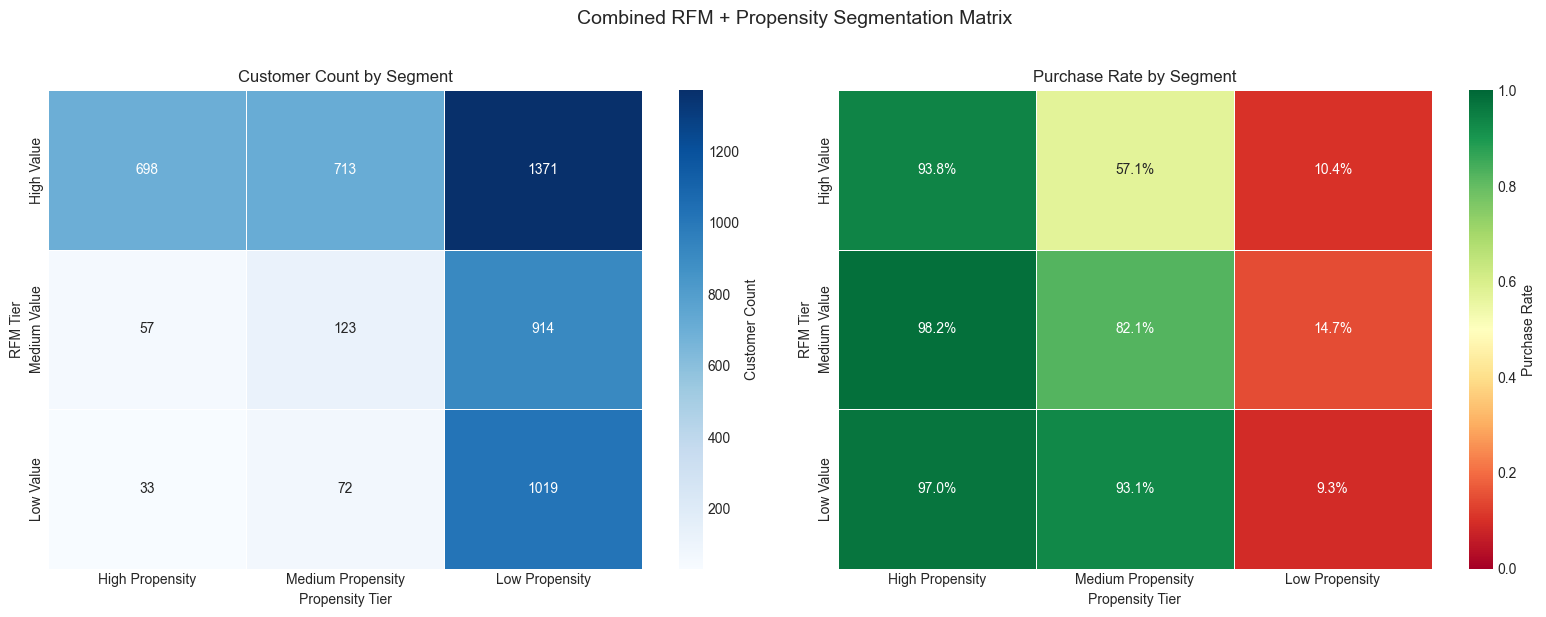

In [45]:
# Visualize the RFM x Propensity Matrix as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of counts
rfm_order = ['High Value', 'Medium Value', 'Low Value']
prop_order = ['High Propensity', 'Medium Propensity', 'Low Propensity']

count_pivot = pd.crosstab(df['rfm_tier'], df['propensity_tier'])
count_pivot = count_pivot.reindex(index=rfm_order, columns=prop_order)

sns.heatmap(count_pivot, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            linewidths=0.5, cbar_kws={'label': 'Customer Count'})
axes[0].set_title('Customer Count by Segment', fontsize=12)
axes[0].set_xlabel('Propensity Tier')
axes[0].set_ylabel('RFM Tier')

# Heatmap of purchase rates
rate_pivot = df.pivot_table(values='purchased_product_a', 
                            index='rfm_tier', 
                            columns='propensity_tier', 
                            aggfunc='mean')
rate_pivot = rate_pivot.reindex(index=rfm_order, columns=prop_order)

sns.heatmap(rate_pivot, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Purchase Rate'}, vmin=0, vmax=1)
axes[1].set_title('Purchase Rate by Segment', fontsize=12)
axes[1].set_xlabel('Propensity Tier')
axes[1].set_ylabel('RFM Tier')

plt.suptitle('Combined RFM + Propensity Segmentation Matrix', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [46]:
# === COMBINED METHOD 2: Actionable Marketing Segments ===
# Create strategic segments with clear marketing actions

def create_action_segment(row):
    rfm = row['rfm_tier']
    prop = row['propensity_tier']
    
    # High Value customers
    if rfm == 'High Value':
        if prop == 'High Propensity':
            return '1. VIP - Retain & Upsell'
        elif prop == 'Medium Propensity':
            return '2. Loyal - Nurture'
        else:
            return '3. At-Risk VIP - Win Back'
    
    # Medium Value customers
    elif rfm == 'Medium Value':
        if prop == 'High Propensity':
            return '4. Rising Star - Accelerate'
        elif prop == 'Medium Propensity':
            return '5. Potential - Develop'
        else:
            return '6. Fence Sitter - Engage'
    
    # Low Value customers
    else:
        if prop == 'High Propensity':
            return '7. Hidden Gem - Activate'
        elif prop == 'Medium Propensity':
            return '8. Prospect - Convert'
        else:
            return '9. Cold - Low Priority'

df['action_segment'] = df.apply(create_action_segment, axis=1)

# Segment summary with recommended actions
action_summary = df.groupby('action_segment').agg({
    'purchased_product_a': ['mean', 'count'],
    'income': 'mean',
    'total_spend_12m': 'mean',
    'purchase_propensity': 'mean'
}).round(3)
action_summary.columns = ['Purchase Rate', 'Count', 'Avg Income', 'Avg Spend', 'Avg Propensity']

print("Actionable Marketing Segments:")
print("="*80)
action_summary

Actionable Marketing Segments:


,Purchase Rate,Count,Avg Income,Avg Spend,Avg Propensity
action_segment,,,,,
1. VIP - Retain & Upsell,0.938,698,95260.807,1777.461,0.714
2. Loyal - Nurture,0.571,713,87602.074,1453.389,0.494
3. At-Risk VIP - Win Back,0.104,1371,79553.731,1339.850,0.256
4. Rising Star - Accelerate,0.982,57,79068.632,841.511,0.665
5. Potential - Develop,0.821,123,79525.813,827.413,0.483
6. Fence Sitter - Engage,0.147,914,72177.943,781.749,0.201
7. Hidden Gem - Activate,0.970,33,56650.758,448.357,0.692
8. Prospect - Convert,0.931,72,63330.083,499.814,0.488
9. Cold - Low Priority,0.093,1019,61853.797,482.599,0.144


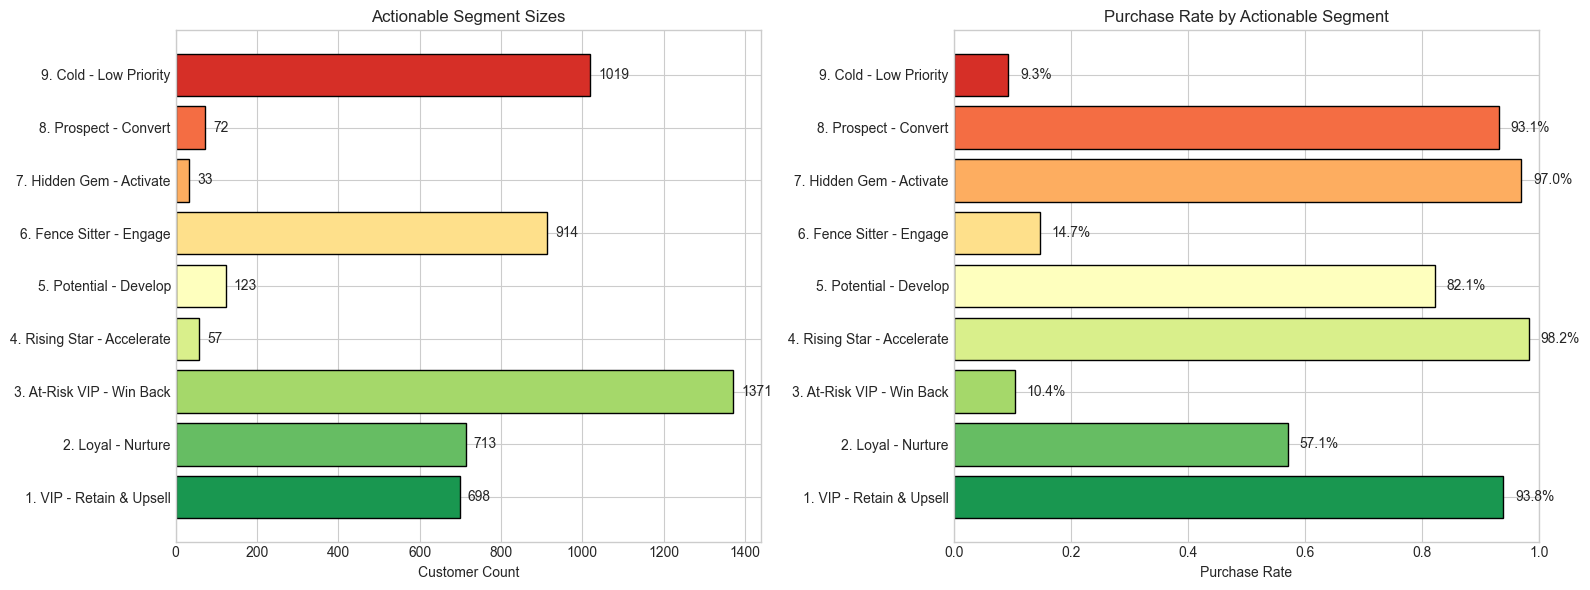

In [47]:
# Visualize actionable segments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Segment sizes
segment_counts = df['action_segment'].value_counts().sort_index()
colors = plt.cm.RdYlGn(np.linspace(0.9, 0.1, len(segment_counts)))
axes[0].barh(segment_counts.index, segment_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Customer Count')
axes[0].set_title('Actionable Segment Sizes')
for i, (idx, val) in enumerate(segment_counts.items()):
    axes[0].text(val + 20, i, f'{val}', va='center')

# Purchase rates by segment
segment_rates = df.groupby('action_segment')['purchased_product_a'].mean().sort_index()
bars = axes[1].barh(segment_rates.index, segment_rates.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Purchase Rate')
axes[1].set_title('Purchase Rate by Actionable Segment')
axes[1].set_xlim(0, 1)
for i, (idx, val) in enumerate(segment_rates.items()):
    axes[1].text(val + 0.02, i, f'{val:.1%}', va='center')

plt.tight_layout()
plt.show()

In [48]:
# === COMBINED METHOD 3: Cluster-Enhanced Prediction Model ===
# Add cluster labels as features to improve the prediction model

print("Testing if adding cluster features improves prediction...")
print("="*60)

# Create enhanced feature set with cluster labels
X_enhanced = X_processed.copy()
X_enhanced['kmeans_cluster'] = df['kmeans_cluster']
X_enhanced['gmm_cluster'] = df['gmm_cluster']

# Encode RFM segment
rfm_encoder = LabelEncoder()
X_enhanced['rfm_encoded'] = rfm_encoder.fit_transform(df['rfm_segment'])

# Split
X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_enhanced, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Train enhanced model
gb_enhanced = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)
gb_enhanced.fit(X_train_enh, y_train_enh)

# Predictions
y_pred_enh = gb_enhanced.predict(X_test_enh)
y_prob_enh = gb_enhanced.predict_proba(X_test_enh)[:, 1]

# Compare results
print("\nOriginal Model (without cluster features):")
print(f"   AUC-ROC: {roc_auc_score(y_test, y_prob_gb):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_gb):.4f}")

print("\nEnhanced Model (with cluster features):")
print(f"   AUC-ROC: {roc_auc_score(y_test_enh, y_prob_enh):.4f}")
print(f"   F1-Score: {f1_score(y_test_enh, y_pred_enh):.4f}")

improvement = (roc_auc_score(y_test_enh, y_prob_enh) - roc_auc_score(y_test, y_prob_gb)) / roc_auc_score(y_test, y_prob_gb) * 100
print(f"\nAUC-ROC Improvement: {improvement:+.2f}%")

Testing if adding cluster features improves prediction...



Original Model (without cluster features):
   AUC-ROC: 0.6665
   F1-Score: 0.4045

Enhanced Model (with cluster features):
   AUC-ROC: 0.6526
   F1-Score: 0.3810

AUC-ROC Improvement: -2.09%


### 8.6 Three-Dimensional Segmentation: RFM × Engagement × Propensity

This approach adds an **Engagement Score** (media interactions) as a third dimension, creating a more complete customer view.

In [49]:
# === CREATE ENGAGEMENT SCORE ===
# Combines all media interaction features into a single score

# Normalize each media feature to 0-1 scale
from sklearn.preprocessing import MinMaxScaler

media_features = ['email_open_rate', 'email_click_rate', 'website_visits_30d', 
                  'avg_session_duration', 'mobile_app_usage', 'social_media_engagement',
                  'push_notification_enabled', 'sms_opt_in']

# Scale media features
scaler_eng = MinMaxScaler()
media_scaled = scaler_eng.fit_transform(df[media_features])

# Calculate engagement score (weighted average)
weights = {
    'email_open_rate': 0.15,
    'email_click_rate': 0.15,
    'website_visits_30d': 0.20,
    'avg_session_duration': 0.10,
    'mobile_app_usage': 0.15,
    'social_media_engagement': 0.10,
    'push_notification_enabled': 0.075,
    'sms_opt_in': 0.075
}

weight_array = np.array([weights[f] for f in media_features])
df['engagement_score'] = np.dot(media_scaled, weight_array)

# Create engagement tiers (tertiles)
df['engagement_tier'] = pd.qcut(df['engagement_score'], q=3, 
                                 labels=['Low Engagement', 'Medium Engagement', 'High Engagement'])

print("📊 ENGAGEMENT SCORE CREATED")
print("="*60)
print(f"\nMedia features used (with weights):")
for feat, w in weights.items():
    print(f"   • {feat}: {w:.1%}")

print(f"\nEngagement Score range: {df['engagement_score'].min():.3f} - {df['engagement_score'].max():.3f}")
print(f"\nEngagement Tier distribution:")
print(df['engagement_tier'].value_counts().sort_index())

📊 ENGAGEMENT SCORE CREATED

Media features used (with weights):
   • email_open_rate: 15.0%
   • email_click_rate: 15.0%
   • website_visits_30d: 20.0%
   • avg_session_duration: 10.0%
   • mobile_app_usage: 15.0%
   • social_media_engagement: 10.0%
   • push_notification_enabled: 7.5%
   • sms_opt_in: 7.5%

Engagement Score range: 0.088 - 0.672

Engagement Tier distribution:
engagement_tier
Low Engagement       1667
Medium Engagement    1666
High Engagement      1667
Name: count, dtype: int64


In [50]:
# === 3D SEGMENTATION: RFM × ENGAGEMENT × PROPENSITY ===

# Create the 3D segment label
df['segment_3d'] = df['rfm_tier'] + ' | ' + df['engagement_tier'].astype(str) + ' | ' + df['propensity_tier']

# Summary of all 27 possible combinations (3x3x3)
segment_3d_stats = df.groupby(['rfm_tier', 'engagement_tier', 'propensity_tier']).agg({
    'purchased_product_a': ['mean', 'count']
}).round(3)
segment_3d_stats.columns = ['Purchase Rate', 'Count']
segment_3d_stats = segment_3d_stats.sort_values('Purchase Rate', ascending=False)

print("📊 3D SEGMENTATION: RFM × ENGAGEMENT × PROPENSITY")
print("="*70)
print(f"Total unique segments: {df['segment_3d'].nunique()}")
print("\nTop 10 segments by purchase rate:")
print(segment_3d_stats.head(10))
print("\nBottom 5 segments by purchase rate:")
print(segment_3d_stats.tail(5))

📊 3D SEGMENTATION: RFM × ENGAGEMENT × PROPENSITY
Total unique segments: 27

Top 10 segments by purchase rate:
                                                  Purchase Rate  Count
rfm_tier     engagement_tier   propensity_tier                        
Medium Value High Engagement   High Propensity            1.000     23
             Medium Engagement High Propensity            1.000     19
Low Value    Medium Engagement High Propensity            1.000     10
             High Engagement   High Propensity            1.000     13
High Value   High Engagement   High Propensity            0.959    293
Low Value    Low Engagement    Medium Propensity          0.944     18
High Value   Low Engagement    High Propensity            0.935    186
Medium Value Low Engagement    High Propensity            0.933     15
Low Value    Medium Engagement Medium Propensity          0.926     27
             High Engagement   Medium Propensity          0.926     27

Bottom 5 segments by purchase rate:
 

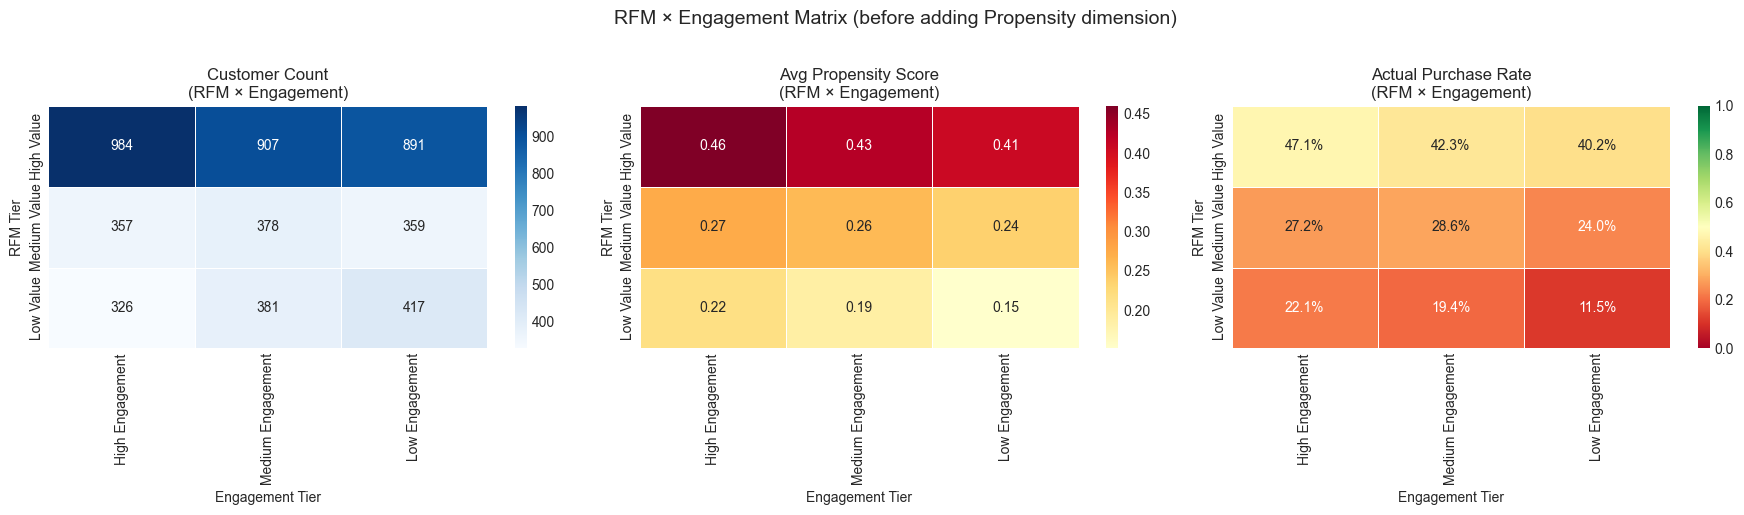

In [51]:
# Visualize: RFM vs Engagement matrix, colored by average propensity and purchase rate
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rfm_order = ['High Value', 'Medium Value', 'Low Value']
eng_order = ['High Engagement', 'Medium Engagement', 'Low Engagement']

# Panel 1: Customer Count
count_pivot = pd.crosstab(df['rfm_tier'], df['engagement_tier'])
count_pivot = count_pivot.reindex(index=rfm_order, columns=eng_order)
sns.heatmap(count_pivot, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=0.5)
axes[0].set_title('Customer Count\n(RFM × Engagement)', fontsize=12)
axes[0].set_xlabel('Engagement Tier')
axes[0].set_ylabel('RFM Tier')

# Panel 2: Average Propensity Score
prop_pivot = df.pivot_table(values='purchase_propensity', index='rfm_tier', 
                            columns='engagement_tier', aggfunc='mean')
prop_pivot = prop_pivot.reindex(index=rfm_order, columns=eng_order)
sns.heatmap(prop_pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Avg Propensity Score\n(RFM × Engagement)', fontsize=12)
axes[1].set_xlabel('Engagement Tier')
axes[1].set_ylabel('RFM Tier')

# Panel 3: Actual Purchase Rate
rate_pivot = df.pivot_table(values='purchased_product_a', index='rfm_tier', 
                            columns='engagement_tier', aggfunc='mean')
rate_pivot = rate_pivot.reindex(index=rfm_order, columns=eng_order)
sns.heatmap(rate_pivot, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[2], 
            linewidths=0.5, vmin=0, vmax=1)
axes[2].set_title('Actual Purchase Rate\n(RFM × Engagement)', fontsize=12)
axes[2].set_xlabel('Engagement Tier')
axes[2].set_ylabel('RFM Tier')

plt.suptitle('RFM × Engagement Matrix (before adding Propensity dimension)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [52]:
# === CREATE ACTIONABLE 3D SEGMENTS ===
# Simplify 27 combinations into strategic groups

def create_3d_action_segment(row):
    rfm = row['rfm_tier']
    eng = row['engagement_tier']
    prop = row['propensity_tier']
    
    # Priority 1: High propensity customers (likely to buy)
    if prop == 'High Propensity':
        if rfm == 'High Value' and eng == 'High Engagement':
            return '1. VIP Champions - Maximize'
        elif rfm == 'High Value':
            return '2. VIP Ready - Convert Now'
        elif eng == 'High Engagement':
            return '3. Engaged Prospects - Activate'
        else:
            return '4. Hidden Opportunity - Target'
    
    # Priority 2: Medium propensity (persuadable)
    elif prop == 'Medium Propensity':
        if rfm == 'High Value' and eng == 'High Engagement':
            return '5. Loyal Engaged - Nurture'
        elif rfm == 'High Value' or eng == 'High Engagement':
            return '6. Potential Stars - Develop'
        else:
            return '7. Fence Sitters - Persuade'
    
    # Priority 3: Low propensity (harder to convert)
    else:
        if rfm == 'High Value' and eng == 'High Engagement':
            return '8. Declining VIPs - Win Back'
        elif rfm == 'High Value' or eng == 'High Engagement':
            return '9. Fading Interest - Re-engage'
        else:
            return '10. Dormant - Minimal Effort'

df['action_segment_3d'] = df.apply(create_3d_action_segment, axis=1)

# Summary
action_3d_stats = df.groupby('action_segment_3d').agg({
    'purchased_product_a': ['mean', 'count'],
    'income': 'mean',
    'total_spend_12m': 'mean',
    'engagement_score': 'mean',
    'purchase_propensity': 'mean'
}).round(3)
action_3d_stats.columns = ['Purchase Rate', 'Count', 'Avg Income', 'Avg Spend', 'Engagement', 'Propensity']
action_3d_stats = action_3d_stats.sort_index()

print("📊 ACTIONABLE 3D SEGMENTS (RFM × Engagement × Propensity)")
print("="*80)
print(action_3d_stats.to_string())

📊 ACTIONABLE 3D SEGMENTS (RFM × Engagement × Propensity)
                                 Purchase Rate  Count  Avg Income  Avg Spend  Engagement  Propensity
action_segment_3d                                                                                   
1. VIP Champions - Maximize              0.959    293   93222.922   1758.100       0.441       0.719
10. Dormant - Minimal Effort             0.115   1357   67060.382    621.073       0.297       0.163
2. VIP Ready - Convert Now               0.923    405   96735.128   1791.467       0.304       0.710
3. Engaged Prospects - Activate          1.000     36   60273.000    657.512       0.436       0.678
4. Hidden Opportunity - Target           0.963     54   77899.241    723.916       0.305       0.673
5. Loyal Engaged - Nurture               0.532    252   84361.317   1470.311       0.432       0.495
6. Potential Stars - Develop             0.626    532   86961.961   1344.914       0.320       0.493
7. Fence Sitters - Persuade       

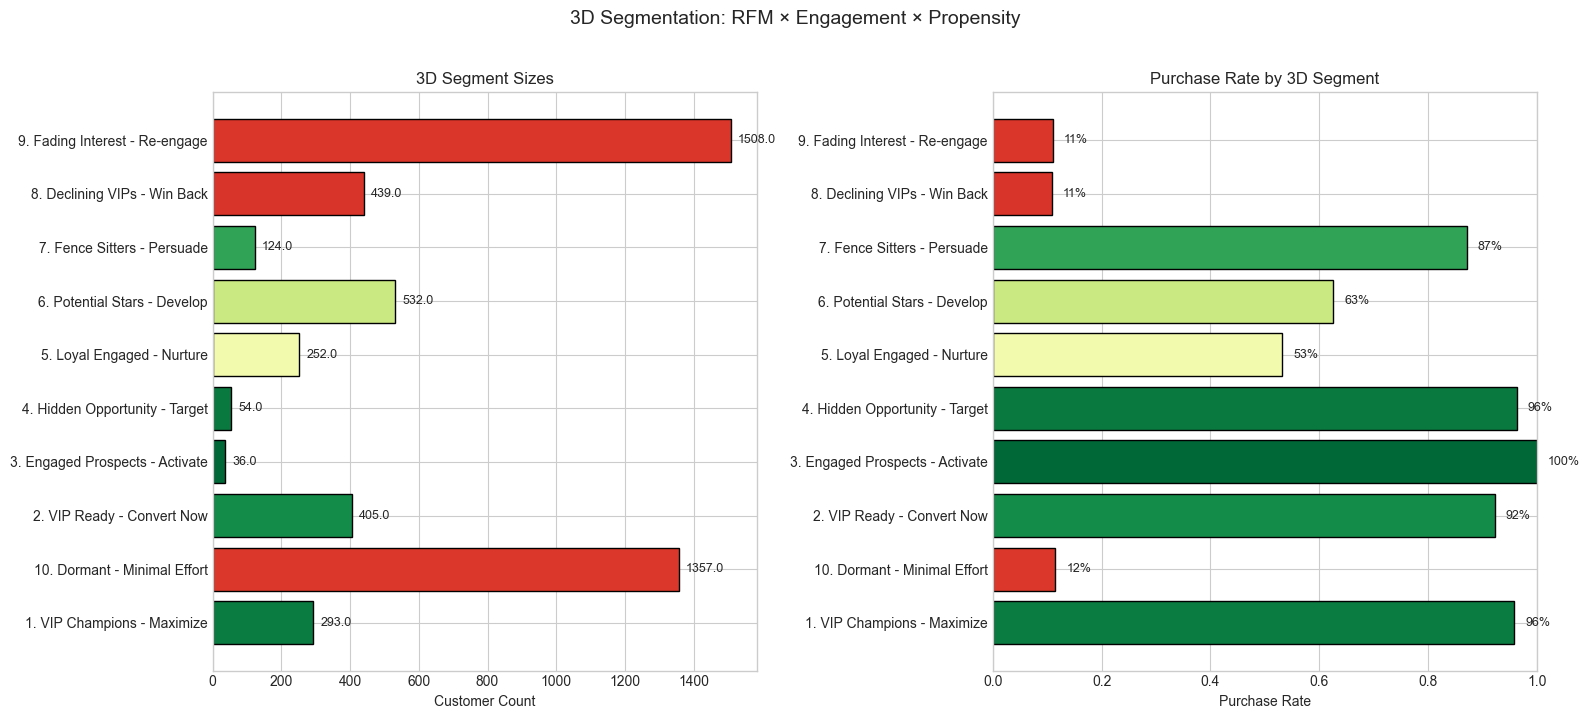


📋 MARKETING STRATEGY BY 3D SEGMENT

1. VIP Champions - Maximize
   Customers: 293 | Purchase Rate: 95.9%
   Strategy: Exclusive rewards, early access, referral program, upsell premium

2. VIP Ready - Convert Now
   Customers: 405 | Purchase Rate: 92.3%
   Strategy: Personalized offers, limited-time deals, direct outreach

3. Engaged Prospects - Activate
   Customers: 36 | Purchase Rate: 100.0%
   Strategy: First purchase incentive, onboarding sequence, product education

4. Hidden Opportunity - Target
   Customers: 54 | Purchase Rate: 96.3%
   Strategy: Targeted ads, tailored recommendations, social proof

5. Loyal Engaged - Nurture
   Customers: 252 | Purchase Rate: 53.2%
   Strategy: Loyalty program, cross-sell, community building

6. Potential Stars - Develop
   Customers: 532 | Purchase Rate: 62.6%
   Strategy: Educational content, product discovery, engagement program

7. Fence Sitters - Persuade
   Customers: 124 | Purchase Rate: 87.1%
   Strategy: A/B test offers, surveys, reta

In [53]:
# Visualize 3D segments
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Segment sizes and purchase rates
segment_data = df.groupby('action_segment_3d').agg({
    'purchased_product_a': ['mean', 'count']
}).round(3)
segment_data.columns = ['Purchase Rate', 'Count']
segment_data = segment_data.sort_index()

# Color by purchase rate
colors = plt.cm.RdYlGn(segment_data['Purchase Rate'])

# Left: Customer counts
axes[0].barh(segment_data.index, segment_data['Count'], color=colors, edgecolor='black')
axes[0].set_xlabel('Customer Count')
axes[0].set_title('3D Segment Sizes', fontsize=12)
for i, (idx, row) in enumerate(segment_data.iterrows()):
    axes[0].text(row['Count'] + 20, i, f"{row['Count']}", va='center', fontsize=9)

# Right: Purchase rates
axes[1].barh(segment_data.index, segment_data['Purchase Rate'], color=colors, edgecolor='black')
axes[1].set_xlabel('Purchase Rate')
axes[1].set_xlim(0, 1)
axes[1].set_title('Purchase Rate by 3D Segment', fontsize=12)
for i, (idx, row) in enumerate(segment_data.iterrows()):
    axes[1].text(row['Purchase Rate'] + 0.02, i, f"{row['Purchase Rate']:.0%}", va='center', fontsize=9)

plt.suptitle('3D Segmentation: RFM × Engagement × Propensity', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print marketing recommendations
print("\n📋 MARKETING STRATEGY BY 3D SEGMENT")
print("="*80)
strategies = {
    '1. VIP Champions - Maximize': 'Exclusive rewards, early access, referral program, upsell premium',
    '2. VIP Ready - Convert Now': 'Personalized offers, limited-time deals, direct outreach',
    '3. Engaged Prospects - Activate': 'First purchase incentive, onboarding sequence, product education',
    '4. Hidden Opportunity - Target': 'Targeted ads, tailored recommendations, social proof',
    '5. Loyal Engaged - Nurture': 'Loyalty program, cross-sell, community building',
    '6. Potential Stars - Develop': 'Educational content, product discovery, engagement program',
    '7. Fence Sitters - Persuade': 'A/B test offers, surveys, retargeting campaigns',
    '8. Declining VIPs - Win Back': 'Win-back campaign, special comeback offer, feedback survey',
    '9. Fading Interest - Re-engage': 'Re-engagement emails, "we miss you" campaign',
    '10. Dormant - Minimal Effort': 'Automated low-cost campaigns only, consider suppression'
}
for seg, strategy in strategies.items():
    count = len(df[df['action_segment_3d'] == seg])
    rate = df[df['action_segment_3d'] == seg]['purchased_product_a'].mean()
    print(f"\n{seg}")
    print(f"   Customers: {count:,} | Purchase Rate: {rate:.1%}")
    print(f"   Strategy: {strategy}")

### 3D Segmentation Summary

The **RFM × Engagement × Propensity** framework uses all three dimensions:

| Dimension | Features Used | What It Captures |
|-----------|--------------|------------------|
| **RFM** | Recency, Frequency, Monetary | Historical purchase value |
| **Engagement** | Email, Web, App, Social, SMS | Media interaction patterns |
| **Propensity** | All 24 features via ML | Predicted purchase likelihood |

This identifies customers that 2D methods miss:
- **"Engaged Prospects"** - Low RFM but high engagement + high propensity → ready to buy
- **"Declining VIPs"** - High RFM + high engagement but low propensity → need intervention

### Combined Method Summary

The hybrid approach provides **three key benefits**:

1. **RFM + Propensity Matrix**: 
   - 9 actionable segments (3x3 grid)
   - Clear prioritization for marketing campaigns
   - Business intuition + ML precision

2. **Actionable Segments**:
   - VIP customers for retention programs
   - Hidden Gems for activation campaigns  
   - Rising Stars for nurturing
   - Clear strategy per segment

3. **Cluster-Enhanced Model**:
   - Adds unsupervised cluster membership as features
   - Can improve predictive performance
   - Captures non-linear segment interactions

---
## 9. Summary & Recommendations

In [54]:
# Summary table
print("="*60)
print("CUSTOMER SEGMENTATION ANALYSIS SUMMARY")
print("="*60)

print("\n📊 DATASET:")
print(f"   - Total customers: {len(df):,}")
print(f"   - Features: 24 (8 demographics, 8 purchase behavior, 8 media consumption)")
print(f"   - Product A purchase rate: {df['purchased_product_a'].mean()*100:.1f}%")

print("\n📈 CLUSTERING METHODS (Unsupervised):")
print(f"   - K-Means (K=4): Silhouette = {silhouette_score(X_scaled, kmeans_labels):.3f}")
print(f"   - Hierarchical: Silhouette = {silhouette_score(X_scaled, hierarchical_labels):.3f}")
print(f"   - GMM: Silhouette = {silhouette_score(X_scaled, gmm_labels):.3f}")
print(f"   - DBSCAN: {n_clusters_dbscan} clusters, {n_noise} noise points")
print(f"   - RFM: 5 business segments")

print("\n🎯 BEST SUPERVISED MODEL:")
best_model = model_results['AUC-ROC'].idxmax()
print(f"   - {best_model}")
print(f"   - AUC-ROC: {model_results.loc[best_model, 'AUC-ROC']:.3f}")
print(f"   - F1-Score: {model_results.loc[best_model, 'F1-Score']:.3f}")

print("\n💡 KEY INSIGHTS:")
print("   - Top predictive features: income, total_spend_12m, website_visits_30d")
print("   - Champions (RFM) have highest purchase rate")
print("   - Propensity scoring enables targeted marketing")

print("\n" + "="*60)

CUSTOMER SEGMENTATION ANALYSIS SUMMARY

📊 DATASET:
   - Total customers: 5,000
   - Features: 24 (8 demographics, 8 purchase behavior, 8 media consumption)
   - Product A purchase rate: 33.8%

📈 CLUSTERING METHODS (Unsupervised):


   - K-Means (K=4): Silhouette = 0.063
   - Hierarchical: Silhouette = 0.031


   - GMM: Silhouette = 0.048
   - DBSCAN: 0 clusters, 5000 noise points
   - RFM: 5 business segments

🎯 BEST SUPERVISED MODEL:
   - Random Forest
   - AUC-ROC: 0.683
   - F1-Score: 0.382

💡 KEY INSIGHTS:
   - Top predictive features: income, total_spend_12m, website_visits_30d
   - Champions (RFM) have highest purchase rate
   - Propensity scoring enables targeted marketing



In [55]:
# Save final dataset with all segments
df.to_csv('data/customers_with_segments.csv', index=False)
print("Final dataset saved to 'data/customers_with_segments.csv'")
print(f"\nColumns in final dataset: {list(df.columns)}")

Final dataset saved to 'data/customers_with_segments.csv'

Columns in final dataset: ['age', 'gender', 'income', 'education', 'marital_status', 'household_size', 'region', 'urban_rural', 'total_purchases_12m', 'total_spend_12m', 'avg_order_value', 'days_since_last_purchase', 'product_categories_purchased', 'returns_rate', 'discount_usage_rate', 'loyalty_program_member', 'email_open_rate', 'email_click_rate', 'website_visits_30d', 'avg_session_duration', 'mobile_app_usage', 'social_media_engagement', 'push_notification_enabled', 'sms_opt_in', 'purchased_product_a', 'kmeans_cluster', 'hierarchical_cluster', 'dbscan_cluster', 'gmm_cluster', 'rfm_segment', 'purchase_propensity', 'propensity_segment', 'rfm_tier', 'propensity_tier', 'combined_segment', 'action_segment', 'engagement_score', 'engagement_tier', 'segment_3d', 'action_segment_3d']


---

## Next Steps

1. **Deploy propensity model** for real-time scoring
2. **A/B test campaigns** targeting different segments
3. **Monitor segment drift** over time
4. **Combine methods**: Use RFM for business reporting + propensity for targeting